# GlobalShop Direct - Segmentation clients par la méthode RFM

### Projet d’apprentissage non supervisé réalisé en binôme

**Auteurs :** [Josephine et Loïc]
]  
**Formation :** Data Analyst - Simplon    
**Source de données :** Online_Retail.xlsx

---

## 1. Introduction et contexte du projet

Dans le cadre de ce projet pédagogique, la direction marketing de
GlobalShop Direct souhaite mieux comprendre les comportements d’achat
de ses clients pour adapter ses actions commerciales.

La base disponible contient des transactions : produits achetés,
quantités, prix, dates de facturation et identifiants clients.
Ces données doivent être nettoyées et regroupées au niveau client
avant de permettre une segmentation.

Nous utiliserons la méthode RFM pour décrire chaque client selon :
- la **Récence** de son dernier achat ;
- la **Fréquence** de ses commandes ;
- le **Montant** total de ses achats sur la période étudiée.

Nous appliquerons ensuite des méthodes d’apprentissage non supervisé
pour identifier des groupes de clients présentant des comportements
similaires.

Les résultats seront présentés dans un dashboard Data Studio et dans
un support de présentation destiné à la direction marketing.

## 2. Problématique et objectifs métier

### Problématique

Comment transformer les historiques d’achats de GlobalShop Direct
en segments clients interprétables et exploitables par les équipes marketing ?

### Questions métier

1. Quels clients ont acheté récemment et commandent régulièrement ?
2. Quels clients contribuent le plus au montant des achats ?
3. Quels clients n’ont pas acheté depuis longtemps ?
4. Quels groupes présentent des comportements d’achat similaires ?
5. Quelles actions marketing proposer à chaque segment ?
6. Comment attribuer un segment à un profil RFM saisi dans une application ?

### Objectifs analytiques

- Évaluer et améliorer la qualité des transactions.
- Construire un dataset RFM contenant une ligne par client.
- Étudier les distributions et préparer les variables pour le clustering.
- Comparer plusieurs nombres de clusters et, si pertinent, plusieurs méthodes.
- Interpréter les segments à partir des valeurs RFM d’origine.
- Préparer les données et le modèle nécessaires au dashboard Streamlit.

### Critères de réussite

La segmentation doit être :
- reproductible à partir des données sources ;
- justifiée par des indicateurs et des analyses visuelles ;
- compréhensible pour une équipe marketing ;
- associée à des recommandations concrètes.

La qualité mathématique des clusters ne suffit pas :
leur utilité métier doit également être examinée.

## 3. Principe de l’apprentissage non supervisé

L’apprentissage non supervisé consiste à rechercher une structure
dans les données sans disposer de catégories de référence.

Dans ce projet, aucun segment marketing n’est fourni au départ.
Les algorithmes regroupent les clients selon la proximité de leurs
profils RFM : cette opération s’appelle le **clustering**.

Nous étudierons :
- **K-Means**, qui affecte les clients à des groupes autour de centres
  appelés centroïdes ;
- le **clustering hiérarchique**, qui construit progressivement
  des regroupements de clients.

Nous utiliserons également la **PCA**, ou analyse en composantes principales,
pour représenter les profils dans un espace à deux dimensions.

Les numéros de clusters sont de simples identifiants.
Leurs noms marketing seront définis après l’analyse des profils.

## 4. Présentation des données sources

Le fichier utilisé est `Online_Retail.xlsx`, feuille `Online Retail`.

Une ligne représente une ligne de facture.
Une même facture peut contenir plusieurs lignes correspondant à différents produits.

| Variable | Définition | Utilité dans le projet |
|---|---|---|
| InvoiceNo | Identifiant de facture | Compter les commandes distinctes et repérer les annulations |
| StockCode | Code du produit | Identifier les articles et examiner les anomalies |
| Description | Description du produit | Comprendre le contenu des transactions |
| Quantity | Quantité enregistrée sur la ligne | Repérer les retours et calculer le montant |
| InvoiceDate | Date et heure de facturation | Définir la période et calculer la récence |
| UnitPrice | Prix unitaire | Calculer le montant et repérer les prix invalides |
| CustomerID | Identifiant du client | Regrouper les transactions par client |
| Country | Pays associé à la transaction | Décrire le périmètre géographique |

### Variables dérivées

| Variable | Définition | Unité |
|---|---|---|
| LineAmount | Quantity × UnitPrice | Unité monétaire du fichier |
| Recency | Jours depuis le dernier achat à la date de référence | Jours |
| Frequency | Nombre de factures d’achat distinctes par client | Commandes |
| Monetary | Somme des montants des lignes d’achat retenues | Unité monétaire du fichier |
| Cluster | Groupe attribué par le modèle | Identifiant |
| Segment | Nom métier attribué après profilage | Catégorie |

CustomerID, InvoiceNo et StockCode sont des identifiants,
même lorsqu’ils apparaissent sous forme numérique.
Ils ne seront pas utilisés comme variables de distance pour le clustering.

La devise doit être confirmée dans la documentation de la source
avant d’étiqueter les montants dans le dashboard.

## 5. Méthodologie d’analyse

Notre démarche suit huit étapes :

1. **Cadrer le besoin métier**
   Définir les objectifs et les questions auxquelles répondre.

2. **Explorer les transactions**
   Examiner la structure, la période, les valeurs manquantes et les anomalies.

3. **Nettoyer les données**
   Appliquer des règles explicites et mesurer leur impact.

4. **Construire les profils RFM**
   Agréger les achats pour obtenir une ligne par client.

5. **Préparer les variables**
   Étudier l’asymétrie, appliquer les transformations retenues
   et standardiser les variables.

6. **Construire et évaluer les clusters**
   Comparer plusieurs valeurs de K et examiner la cohérence des groupes.

7. **Interpréter les segments**
   Décrire les profils sur les valeurs RFM d’origine et proposer des actions.

8. **Restituer les résultats**
   Préparer le dashboard et une synthèse destinée au marketing.

### Organisation des données

Nous conserverons des objets distincts :
- `df_raw` : transactions sources ;
- `df_clean` : transactions nettoyées ;
- `rfm` : indicateurs clients dans leurs unités d’origine ;
- `rfm_log` : indicateurs transformés par logarithme ;
- `X_scaled` : variables standardisées utilisées pour le clustering ;
- `rfm_segments` : profils RFM enrichis des clusters et segments ;
- `df_pca` : coordonnées de projection pour les visualisations.

## 1. Comprendre les trois indicateurs RFM

Le RFM résume le comportement d’un client avec trois variables :

| Indicateur | Définition simple | Calcul envisagé | Lecture métier |
| :--- | :--- | :--- | :--- |
| **Récence — R** | Nombre de jours depuis le dernier achat | $\text{Date de référence} - \text{Date du dernier achat}$ | Une récence faible indique un achat récent. |
| **Fréquence — F** | Nombre d’achats distincts | Nombre de factures d’achat distinctes | Une fréquence élevée indique des achats répétés. |
| **Montant — M** | Total dépensé sur la période étudiée | $\sum (\text{Quantity} \times \text{UnitPrice})$ | Un montant élevé indique une forte contribution au chiffre d’affaires. |

> ⚠️ **Attention :** Une ligne de transaction ne correspond pas forcément à un achat distinct, car une facture peut contenir plusieurs produits. Nous compterons donc les **factures distinctes** pour calculer la fréquence.

---

### Exemple fictif

| CustomerID | Récence (en jours) | Fréquence | Montant (€) |
| :---: | :---: | :---: | :---: |
| **10001** | 5 | 20 | 4 500 |
| **10002** | 180 | 2 | 90 |
| **10003** | 12 | 3 | 1 200 |

* **Client 10001 :** Achète récemment, souvent, et pour un montant élevé.
* **Client 10002 :** N’a pas acheté depuis longtemps (inactif).
* **Client 10003 :** A réalisé peu d’achats, mais leur montant total est important.

> 💡 **Remarque :** Le clustering cherchera ces ressemblances automatiquement, sans catégories clients définies à l’avance.

## 6. Chargement et exploration des transactions

### Question métier

Les données disponibles permettent-elles de reconstituer
des historiques d’achats fiables au niveau client ?

### Analyses prévues

- Afficher les premières lignes.
- Mesurer le nombre de lignes et de colonnes.
- Examiner les types des variables.
- Identifier les valeurs manquantes.
- Déterminer la période couverte.
- Compter les clients et les factures distincts.
- Repérer les annulations et les quantités ou prix non positifs.
- Examiner les doublons exacts et les valeurs extrêmes.

### Résultats à documenter après exécution

- Dimensions du dataset : [...]
- Période observée : [...]
- Nombre de clients identifiés : [...]
- Nombre de factures distinctes : [...]
- Principaux problèmes de qualité : [...]

### Interprétation

[Expliquer les conséquences de ces observations pour la construction du RFM.]

### Objectifs de cette étape

- Charger le fichier Online_Retail.xlsx.
- Observer les premières transactions.
- Vérifier les dimensions et les noms des colonnes.
- Comprendre ce que représente une ligne.

### Méthode

Nous utilisons Pandas pour lire la feuille `Online Retail`.
Les données sources sont conservées dans un DataFrame nommé `df_raw`.

Aucune suppression ni transformation n’est réalisée à cette étape.

## 1.1 : Importation des bibliothèques

Nous utilisons :
- **Pandas** pour charger et explorer les tableaux ;
- **NumPy** pour les calculs numériques ;
- **Matplotlib et Seaborn** pour les visualisations.

In [1]:
import os

# Set OMP_NUM_THREADS environment variable to 1
os.environ['OMP_NUM_THREADS'] = '1'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
print("Début du chargement…", flush=True)

df_raw = pd.read_csv(
    "../data/online_retail.csv",
    parse_dates=["InvoiceDate"]
)

print("Chargement terminé :", df_raw.shape)

Début du chargement…


Chargement terminé : (541909, 8)


In [4]:
display(df_raw.head())
print("\nNoms des colonnes:")
print(df_raw.columns.tolist())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Noms des colonnes:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


## 1.3 : Première lecture et dimensions du dataset

### Comprendre une ligne

Une ligne représente une ligne de facture : un article, sa quantité
et son prix unitaire.

Une facture peut contenir plusieurs lignes.
Le nombre de lignes ne correspond donc pas au nombre de commandes.

### Dictionnaire des variables

| Variable | Signification | Utilité pour l’analyse |
|---|---|---|
| InvoiceNo | Identifiant de facture | Compter les commandes distinctes et repérer les annulations |
| StockCode | Code produit | Identifier les articles |
| Description | Description du produit | Comprendre les transactions |
| Quantity | Quantité enregistrée | Calculer les montants et repérer les retours |
| InvoiceDate | Date et heure de facturation | Calculer la récence et déterminer la période |
| UnitPrice | Prix unitaire | Calculer le montant des achats |
| CustomerID | Identifiant client | Construire une ligne RFM par client |
| Country | Pays associé à la transaction | Décrire le périmètre géographique |

CustomerID, InvoiceNo et StockCode sont des identifiants :
leur éventuel format numérique ne leur donne pas un sens quantitatif.

## 1.4 :Structure et types des variables

Nous vérifions :
- le type de chaque colonne ;
- le nombre de valeurs renseignées ;
- la reconnaissance des dates ;
- le format des quantités et des prix.

Cette vérification permet d’anticiper les conversions nécessaires avant les calculs.

In [5]:
#Affichage des types et le nombre de valeurs non manquantes:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  str           
 1   StockCode    541909 non-null  str           
 2   Description  540455 non-null  str           
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), str(4)
memory usage: 59.5 MB


### Interprétation de la structure des données

Le dataset contient **541 909 lignes et 8 colonnes**.

- `InvoiceDate` est reconnue comme une date : elle permet les calculs
  nécessaires à la récence.
- `Quantity` et `UnitPrice` sont numériques : elles permettent de calculer
  les montants des lignes.
- `InvoiceNo` et `StockCode` sont des identifiants de type `object`.Identifiant pouvant contenir des nombres et du texte ou Code produit pouvant contenir des lettres.
- `CustomerID` est lu comme un nombre décimal en `float64`, mais représente un identifiant client, et non une mesure quantitative.

Deux colonnes présentent des valeurs manquantes :
- **Description :** 1 454 valeurs manquantes.
- **CustomerID :** 135 080 valeurs manquantes.

L’absence de CustomerID empêche de rattacher une transaction à un client.
L’absence de description produit n’empêche pas nécessairement le calcul des indicateurs RFM.

Nous allons quantifier ces valeurs manquantes avant de définir les traitements à appliquer.

## 1.5:Analyse des valeurs manquantes

### Question métier

Quelle proportion des transactions ne peut pas être rattachée
à un client identifié ?

### Méthode

Calculer, pour chaque colonne :
- le nombre de valeurs manquantes ;
- leur pourcentage par rapport au nombre total de lignes.

In [6]:
# Compter les valeurs manquantes dans chaque colonne
nb_manquants = df_raw.isna().sum()

#Calculer leur proportion par rappory au nombre de lignes:
pct_manquants = (nb_manquants/ len(df_raw) * 100).round(2)

#Construction d'un tableau de diagnostic:
bilan_manquants = pd.DataFrame({"Nombre_manquant": nb_manquants, "Pourcentage_manquant":pct_manquants})

display(bilan_manquants.sort_values("Nombre_manquant",ascending=False))

,Nombre_manquant,Pourcentage_manquant
CustomerID,135080,24.93
Description,1454,0.27
InvoiceNo,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


### Interprétation et conséquences pour le nettoyage

La colonne `CustomerID` contient **135 080 valeurs manquantes**,
soit **24,93 % des lignes**. Ces transactions ne peuvent pas être
attribuées à un client et seront exclues de la construction du RFM.

Cette proportion concerne les lignes de facture :
elle ne représente pas une proportion de clients ni de chiffre d’affaires.

La colonne `Description` contient **1 454 valeurs manquantes**,
soit **0,27 % des lignes**. Une description absente ne justifie pas,
à elle seule, l’exclusion d’une transaction pour le calcul du RFM.

Les autres colonnes ne présentent aucune valeur manquante.
Cela ne garantit pas l’absence de valeurs invalides.

Aucune suppression n’est réalisée à cette étape.

## 1.6: Période et volumes observés

### Questions métier

- Quelle période les transactions couvrent-elles ?
- Combien de clients identifiés sont présents ?
- Combien de références de facture distinctes sont enregistrées ?
- Combien de pays sont représentés ?

### Méthode

Nous utilisons :
- `min()` et `max()` pour déterminer les dates extrêmes ;
- `nunique()` pour compter les valeurs distinctes.

Ces résultats décrivent les données brutes.
Les références de facture incluent encore les éventuelles annulations.

In [7]:
# Déterminer la période couverte par les transactions
date_debut = df_raw["InvoiceDate"].min()
date_fin = df_raw["InvoiceDate"].max()

print("Première transaction :", date_debut)
print("Dernière transaction :", date_fin)

# Compter les valeurs distinctes
# nunique() ignore les valeurs manquantes par défaut
print("\nClients identifiés :", df_raw["CustomerID"].nunique())
print("Références de facture distinctes :", df_raw["InvoiceNo"].nunique())
print("Pays représentés :", df_raw["Country"].nunique())

Première transaction : 2010-12-01 08:26:00
Dernière transaction : 2011-12-09 12:50:00

Clients identifiés : 4372
Références de facture distinctes : 25900
Pays représentés : 38


## 1.7 — Renommage des colonnes en français

### Objectif

Faciliter la lecture du notebook et utiliser des noms explicites
pour la suite de l’analyse.

### Convention de nommage

Les noms sont écrits en minuscules, sans accents ni espaces.
Les mots sont séparés par un underscore `_`.

### Méthode

La méthode Pandas `rename()` permet de remplacer les noms des colonnes
à partir d’un dictionnaire de correspondance.

Nous conservons `df_raw` avec les noms de la source et créons
`df_transactions` avec les noms français.

Cette opération change uniquement les noms des colonnes :
les valeurs, les types et le nombre de lignes restent identiques.

In [8]:
display(df_raw.head(6))


# Asocier cahque nom d'origin à son nom français:
noms_colonnes = {"InvoiceNo":"numero_facture",
                 "StockCode":"code_produit",
                 "Description":"description_produit",
                 "Quantity":"quantite",
                 "InvoiceDate":"date_facture",
                 "UnitPrice":"prix_unitaire",
                 "CustomerID":"id_client",
                 "Country":"pays"}

#Creation du tableau de travail avec les noms des variables en français
df_transactions =df_raw.rename(columns=noms_colonnes)
# Observer le résultat
display(df_transactions.head(6))

# Vérifier les noms et les dimensions
print("Colonnes :", df_transactions.columns.tolist())
print("Dimensions :", df_transactions.shape)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom


Colonnes : ['numero_facture', 'code_produit', 'description_produit', 'quantite', 'date_facture', 'prix_unitaire', 'id_client', 'pays']
Dimensions : (541909, 8)


### Vérification du renommage

Les huit colonnes ont été renommées en français.

Le dataset conserve ses dimensions : **541 909 lignes et 8 colonnes**.
Le renommage n’a modifié ni les valeurs ni les types des variables.

Nous utilisons désormais `df_transactions` pour poursuivre l’analyse.
`df_raw` conserve les noms des colonnes de la source.

## 1.8 : Repérage des anomalies avant nettoyage

### Question métier

Quelles transactions nécessitent un traitement avant de construire
des profils clients RFM fiables ?

### Contrôles réalisés

- Références de facture commençant par C : annulations à examiner.
- Quantités négatives : retours ou ajustements possibles.
- Quantités nulles : absence de quantité achetée.
- Prix négatifs ou nuls : transactions à examiner.
- Identifiants clients manquants : transactions non attribuables.
- Doublons exacts : répétitions à vérifier.

### Précautions

Une même ligne peut être concernée par plusieurs contrôles.
Les nombres obtenus ne doivent donc pas être additionnés
pour calculer le total des lignes à supprimer.

Un doublon exact est une ligne dont les huit valeurs sont identiques
à celles d’une autre ligne. Une même facture contenant plusieurs
produits n’est pas, à elle seule, un doublon.

Cette étape réalise un diagnostic : aucune ligne n’est supprimée.

In [9]:
# Lire les numéros de facture comme du texte pour examiner leur préfixe
numeros_facture = (df_transactions["numero_facture"].astype("string").str.strip().str.upper())

# Repérer les lignes dont la facture commence par C
masque_annulation = numeros_facture.str.startswith("C", na=False)

# Compter les lignes concernées par chaque contrôle
diagnostic_anomalies = pd.Series({
    "Lignes de factures commençant par C": masque_annulation.sum(),
    "Quantités négatives": (df_transactions["quantite"] < 0).sum(),
    "Quantités nulles": (df_transactions["quantite"] == 0).sum(),
    "Prix négatifs": (df_transactions["prix_unitaire"] < 0).sum(),
    "Prix nuls": (df_transactions["prix_unitaire"] == 0).sum(),
    "Identifiants clients manquants": (
        df_transactions["id_client"].isna().sum()
    ),
    "Doublons exacts au-delà de la première occurrence": (
        df_transactions.duplicated().sum()
    )
}, name="nombre_lignes")

display(diagnostic_anomalies.to_frame())

,nombre_lignes
Lignes de factures commençant par C,9288
Quantités négatives,10624
Quantités nulles,0
Prix négatifs,2
Prix nuls,2515
Identifiants clients manquants,135080
Doublons exacts au-delà de la première occurrence,5268


## Diagnostic avant nettoyage des données (Préparation RFM)


| Contrôle | Lignes concernées | Interprétation |
| :--- | :---: | :--- |
| **Factures commençant par C** | 9 288 | Lignes associées à des références d’annulation |
| **Quantités négatives** | 10 624 | Retours, annulations ou ajustements possibles |
| **Quantités nulles** | 0 | Aucun cas détecté |
| **Prix négatifs** | 2 | À examiner ; incompatibles avec notre périmètre d’achats positifs |
| **Prix nuls** | 2 515 | Aucun montant d’achat sur ces lignes |
| **Identifiants clients manquants** | 135 080 | Impossible de rattacher ces lignes à un client |
| **Répétitions exactes** | 5 268 | À examiner avant de décider de leur suppression |

---

⚠️️ **Points d'attention :**
* Les **9 288** factures "C" correspondent à des **lignes de facture**, et non à 9 288 factures distinctes.
* **Ne pas additionner ces nombres :** une même ligne peut accumuler plusieurs anomalies (par exemple être à la fois une annulation, avoir une quantité négative et manquer d'identifiant client).

### Résultats du diagnostic des anomalies

Nous avons identifié :
- **9 288 lignes** dont la référence de facture commence par C ;
- **10 624 lignes** avec une quantité négative ;
- aucune quantité nulle ;
- **2 lignes** avec un prix négatif ;
- **2 515 lignes** avec un prix nul ;
- **135 080 lignes** sans identifiant client ;
- **5 268 répétitions exactes** au-delà de la première occurrence.

Ces catégories peuvent se chevaucher.
Leur somme ne représente donc pas le nombre de lignes à supprimer.

Conformément au périmètre du projet, les annulations et retours,
les transactions sans client identifié et les prix non positifs
seront exclus de la construction du RFM.

Les doublons exacts nécessitent un examen complémentaire :
leur présence ne prouve pas automatiquement une erreur de saisie.

### Examen d’exemples de transactions à traiter

L’objectif est de comprendre les anomalies détectées,
en observant notamment les références, les descriptions,
les quantités, les prix et les identifiants clients.

Nous examinons également les quantités négatives dont la référence
ne commence pas par C : le filtre sur les annulations ne suffit
pas nécessairement à exclure toutes les quantités négatives.


In [10]:
# 1. Observer quelques lignes de factures d'annulation
print("Exemples de lignes dont la facture commence par C :")
display(df_transactions.loc[masque_annulation].head(5))

# 2. Examiner les quantités négatives hors références commençant par C
masque_negatif_hors_c = (
    (df_transactions["quantite"] < 0)
    & (~masque_annulation)
)

print("\nQuantités négatives hors factures commençant par C :")
print("Nombre de lignes :", masque_negatif_hors_c.sum())
display(df_transactions.loc[masque_negatif_hors_c].head(5))

# 3. Observer les deux lignes ayant un prix négatif
print("\nLignes avec un prix négatif :")
display(
    df_transactions.loc[df_transactions["prix_unitaire"] < 0]
)

# 4. Observer quelques lignes avec un prix nul
print("\nExemples de lignes avec un prix nul :")
display(
    df_transactions.loc[df_transactions["prix_unitaire"] == 0].head(5)
)

# 5. Afficher des exemples de doublons, première occurrence incluse
masque_doublons = df_transactions.duplicated(keep=False)

print("\nExemples de lignes appartenant à des groupes de doublons :")
display(
    df_transactions.loc[masque_doublons]
    .sort_values(["numero_facture", "code_produit"], key=lambda s: s.astype(str))
    .head(10)
)

Exemples de lignes dont la facture commence par C :


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom



Quantités négatives hors factures commençant par C :
Nombre de lignes : 1336


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom



Lignes avec un prix négatif :


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom



Exemples de lignes avec un prix nul :


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom



Exemples de lignes appartenant à des groupes de doublons :


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


## 🧹 Justification des filtres de nettoyage

Ces exemples justifient les filtres de nettoyage prévus. Ils montrent aussi que le filtre sur les factures commençant par `C` ne suffit pas : **1 336 lignes** ont une quantité négative sans ce préfixe.

| Observation | Interprétation | Décision |
| :--- | :--- | :--- |
| **Références commençant par `C` et quantités négatives** | Annulations ou écritures de correction | Exclure les références commençant par `C` |
| **Quantités négatives hors `C`** | Les exemples ressemblent à des ajustements, avec prix nul et client absent | Conserver uniquement les quantités strictement positives (`Quantity > 0`) |
| **Prix négatifs (`Adjust bad debt`)** | Écritures d’ajustement de créances, hors achats clients étudiés | Conserver uniquement les prix strictement positifs (`UnitPrice > 0`) |
| **Prix nuls** | Aucun montant d’achat sur ces lignes ; leur origine exacte reste à déterminer | Exclure du périmètre RFM des achats payants |
| **Répétitions identiques** | Doublons possibles, sans preuve suffisante pour toutes les lignes | Les examiner séparément |

---

💡 **Remarque technique :**
Les deux dernières lignes affichées pour le produit `21448` ont des quantités différentes (**2** et **1**). Elles ne sont donc pas identiques entre elles. Chacune peut toutefois avoir une autre occurrence identique ailleurs dans le tableau.

## 1.9 : Synthèse de l’exploration

### Périmètre des données

- **541 909 lignes et 8 colonnes.**
- Période : du **1er décembre 2010 au 9 décembre 2011**.
- **4 372 clients identifiés.**
- **25 900 références de facture distinctes**, annulations incluses.
- **38 pays représentés.**

### Qualité des données

L’exploration révèle des transactions sans identifiant client,
des annulations, des quantités négatives, des prix non positifs
et des répétitions exactes.

Le préfixe C ne repère pas toutes les quantités négatives :
1 336 lignes négatives possèdent une autre référence.

Les deux prix négatifs correspondent à des écritures
décrites comme des ajustements de créances.

### Décisions

Pour construire le RFM des achats payants, nous retiendrons
les transactions :
- associées à un client identifié ;
- dont la référence ne commence pas par C ;
- avec une quantité strictement positive ;
- avec un prix unitaire strictement positif.

Les répétitions exactes seront étudiées séparément avant de décider de leur traitement.

Les descriptions manquantes ne constituent pas, à elles seules, un motif d’exclusion.

# Étape 2 : Nettoyage et validation des transactions

## Objectif

Construire une base d’achats payants attribuables à des clients
pour calculer des indicateurs RFM fiables.

## Question métier

Quelles transactions répondent au périmètre retenu,
et quelle proportion des données est exclue ?

## Méthode

Appliquer successivement les règles définies pendant l’exploration
et enregistrer le nombre de lignes exclues à chaque étape.

Le tableau source reste disponible dans `df_transactions`.
Le tableau de travail est nommé `df_clean`.

## 2.1 : Filtrage des transactions

Les filtres sont appliqués dans cet ordre :
1. identifiant client renseigné ;
2. référence de facture ne commençant pas par C ;
3. quantité strictement positive ;
4. prix unitaire strictement positif.

Les exclusions par motif dépendent de cet ordre, car certaines lignes présentent plusieurs anomalies.

## 2.1 : Règles de nettoyage et traçabilité

### Règles de nettoyage

Conformément au périmètre du projet, nous allons :

- exclure les lignes sans `id_client` ;
- exclure les lignes dont le `numero_facture` commence par C ;
- exclure les retours et les quantités non positives :
  conserver uniquement `quantite > 0` ;
- exclure les prix unitaires non positifs :
  conserver uniquement `prix_unitaire > 0` ;
- vérifier la validité des dates et la présence des champs
  nécessaires aux calculs.

L’exploration n’a détecté aucune valeur manquante dans
`numero_facture`, `date_facture`, `quantite` et `prix_unitaire`.
La colonne `date_facture` est reconnue comme une date.

Les doublons exacts seront examinés avant de décider de leur suppression.
Une répétition de ligne ne sera pas considérée automatiquement
comme une erreur.

Une `description_produit` manquante n’entraîne pas, à elle seule,
l’exclusion d’une transaction exploitable pour le RFM.

### Traçabilité du nettoyage

Un tableau présentera, pour chaque filtre :

- le nombre de lignes avant traitement ;
- le nombre de lignes exclues à cette étape ;
- le nombre de lignes restantes.

Les filtres seront appliqués successivement pour éviter de compter
plusieurs fois une même ligne exclue.

Les exclusions attribuées à chaque motif dépendent de l’ordre
des filtres, car une ligne peut présenter plusieurs anomalies.

Les données avant nettoyage seront conservées dans `df_transactions`.
Les transactions retenues seront stockées dans `df_clean`.

### Limite du périmètre

Le montant RFM représentera les achats payants retenus. Il ne correspondra pas à un chiffre d’affaires net des retours, puisque les retours et annulations sont exclus de l’analyse.

In [11]:
# Partir d'une copie du tableau avant nettoyage
df_clean = df_transactions.copy()

# Préparer les conditions sur le tableau initial
factures_texte = (
    df_transactions["numero_facture"]
    .astype("string")
    .str.strip()
    .str.upper()
)

regles = [
    ("Client identifié", df_transactions["id_client"].notna()),
    (
        "Hors annulations C",
        ~factures_texte.str.startswith("C", na=False)
    ),
    ("Quantité positive", df_transactions["quantite"] > 0),
    ("Prix positif", df_transactions["prix_unitaire"] > 0)
]

# Enregistrer la situation de départ
bilan = [{
    "etape": "Données initiales",
    "lignes_avant": len(df_clean),
    "lignes_exclues": 0,
    "lignes_restantes": len(df_clean)
}]

# Appliquer chaque filtre aux lignes encore présentes
for nom_regle, condition in regles:
    nb_avant = len(df_clean)

    # Aligner la condition sur les indices des lignes restantes
    condition_restante = condition.loc[df_clean.index]
    df_clean = df_clean.loc[condition_restante].copy()

    bilan.append({
        "etape": nom_regle,
        "lignes_avant": nb_avant,
        "lignes_exclues": nb_avant - len(df_clean),
        "lignes_restantes": len(df_clean)
    })

# Présenter le bilan
bilan_nettoyage = pd.DataFrame(bilan)
display(bilan_nettoyage)

# Observer le tableau après filtrage
display(df_clean.head())

# Mesurer l'impact global
nb_exclues = len(df_transactions) - len(df_clean)

print(f"Lignes retenues : {len(df_clean):,}")
print(f"Lignes exclues : {nb_exclues:,}")
print(f"Part exclue : {nb_exclues / len(df_transactions):.2%}")

,etape,lignes_avant,lignes_exclues,lignes_restantes
0,Données initiales,541909,0,541909
1,Client identifié,541909,135080,406829
2,Hors annulations C,406829,8905,397924
3,Quantité positive,397924,0,397924
4,Prix positif,397924,40,397884


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


Lignes retenues : 397,884
Lignes exclues : 144,025
Part exclue : 26.58%


### Interprétation du premier filtrage

Après application successive des quatre règles,
**397 884 lignes sont conservées**.

Au total, **144 025 lignes sont exclues**, soit **26,58 %**
des transactions initiales.

- Le filtre sur l’identifiant client exclut 135 080 lignes.
- Le filtre sur les annulations exclut ensuite 8 905 lignes.
- Le filtre sur les quantités ne retire aucune ligne supplémentaire :
  les quantités négatives ont déjà été éliminées.
- Le filtre sur les prix retire 40 lignes supplémentaires.

Ces nombres correspondent aux exclusions successives,
et non au nombre total d’anomalies de chaque catégorie.

La proportion exclue concerne les lignes :
elle ne représente pas une proportion de clients ou de chiffre d’affaires.

Le nettoyage reste à compléter par l’examen des doublons
et les contrôles finaux.

## 2.2 : Examen des doublons après filtrage

### Question métier

Les transactions retenues contiennent-elles encore des répétitions exactes susceptibles de gonfler les montants d’achat ?

### Méthode

- Compter les répétitions exactes dans `df_clean`.
- Afficher un groupe complet de lignes identiques.
- Distinguer une répétition exacte de plusieurs articles
  appartenant à une même facture.

Sans identifiant unique de ligne ou confirmation de la source, une répétition exacte ne prouve pas automatiquement une erreur.

In [12]:
# Compter les répétitions au-delà de la première occurrence
nb_doublons = df_clean.duplicated().sum()

print("Répétitions exactes après filtrage :", nb_doublons)
print(f"Part des lignes : {nb_doublons / len(df_clean):.2%}")

# Repérer toutes les occurrences des groupes de doublons
masque_doublons = df_clean.duplicated(keep=False)

if masque_doublons.any():
    # Sélectionner une ligne appartenant à un groupe de doublons
    exemple = df_clean.loc[masque_doublons].iloc[0]

    # Retrouver toutes les lignes identiques à cet exemple
    # Deux valeurs manquantes sont ici considérées comme identiques
    valeurs_identiques = (
        df_clean.eq(exemple)
        | (df_clean.isna() & exemple.isna())
    )

    groupe_identique = valeurs_identiques.all(axis=1)

    print("\nExemple d’un groupe complet de lignes identiques :")
    display(df_clean.loc[groupe_identique])
else:
    print("Aucun doublon exact restant.")

Répétitions exactes après filtrage : 5192
Part des lignes : 1.30%



Exemple d’un groupe complet de lignes identiques :


,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom


### Résultats et décision sur les doublons

Après le premier filtrage, nous identifions **5 192 répétitions exactes**,
soit **1,30 % des 397 884 lignes restantes**.

L’exemple examiné contient deux lignes identiques sur les huit colonnes,
avec la même facture, le même produit, la même quantité,
le même prix et le même client.

Pour ce projet, nous faisons l’hypothèse que ces répétitions
correspondent à des doublons d’enregistrement.
Nous conservons la première occurrence de chaque ligne identique.

Cette décision peut réduire les montants et les quantités calculés.
Elle ne modifie pas le nombre de factures distinctes.

### Limite

Sans identifiant unique de ligne ni confirmation de la source,
certaines répétitions pourraient représenter des lignes d’achat légitimes.
La déduplication constitue donc une hypothèse, et non une certitude.

In [13]:
# Conserver les données avant déduplication pour une éventuelle comparaison
df_avant_dedoublonnage = df_clean.copy()

# Observer l'exemple avant traitement
display(
    df_avant_dedoublonnage.loc[
        df_avant_dedoublonnage["numero_facture"].astype("string").eq("536409")
        & df_avant_dedoublonnage["code_produit"].astype("string").eq("22111")
    ]
)

# Conserver une seule occurrence de chaque ligne identique
df_clean = df_avant_dedoublonnage.drop_duplicates(keep="first").copy()

# Ajouter le traitement au bilan existant
ligne_bilan = pd.DataFrame([{
    "etape": "Suppression des répétitions exactes",
    "lignes_avant": len(df_avant_dedoublonnage),
    "lignes_exclues": len(df_avant_dedoublonnage) - len(df_clean),
    "lignes_restantes": len(df_clean)
}])

# Remplacer cette étape si la cellule est réexécutée
bilan_nettoyage = pd.concat([
    bilan_nettoyage.loc[
        bilan_nettoyage["etape"] != "Suppression des répétitions exactes"
    ],
    ligne_bilan
], ignore_index=True)

display(bilan_nettoyage)

print("Dimensions après déduplication :", df_clean.shape)
print("Répétitions exactes restantes :", df_clean.duplicated().sum())

,numero_facture,code_produit,description_produit,quantite,date_facture,prix_unitaire,id_client,pays
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom


,etape,lignes_avant,lignes_exclues,lignes_restantes
0,Données initiales,541909,0,541909
1,Client identifié,541909,135080,406829
2,Hors annulations C,406829,8905,397924
3,Quantité positive,397924,0,397924
4,Prix positif,397924,40,397884
5,Suppression des répétitions exactes,397884,5192,392692


Dimensions après déduplication : (392692, 8)
Répétitions exactes restantes : 0


## 2.3 : Contrôles finaux des transactions nettoyées

### Question métier

Les transactions retenues permettent-elles de calculer
des indicateurs RFM fiables pour chaque client ?

### Contrôles

Nous vérifions :
- la présence des identifiants clients et des références de facture ;
- la présence et le type des dates ;
- l’absence de références commençant par C ;
- des quantités et des prix strictement positifs ;
- l’absence de doublons exacts ;
- la concordance entre les exclusions et le nombre de lignes restantes.

In [14]:
# Préparer les références pour contrôler les annulations
factures_clean = (
    df_clean["numero_facture"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Vérifier chaque règle : True signifie que le contrôle est satisfait
controles = pd.Series({
    "Tableau non vide": len(df_clean) > 0,
    "Clients tous renseignés": df_clean["id_client"].notna().all(),
    "Factures toutes renseignées": (
        factures_clean.notna() & factures_clean.ne("")
    ).all(),
    "Dates toutes renseignées": df_clean["date_facture"].notna().all(),
    "Colonne date au bon type": (
        pd.api.types.is_datetime64_any_dtype(df_clean["date_facture"])
    ),
    "Aucune référence commençant par C": (
        ~factures_clean.str.startswith("C", na=False)
    ).all(),
    "Quantités toutes positives": (df_clean["quantite"] > 0).all(),
    "Prix tous positifs": (df_clean["prix_unitaire"] > 0).all(),
    "Aucun doublon exact": not df_clean.duplicated().any(),
    "Bilan des exclusions cohérent": (
        bilan_nettoyage["lignes_exclues"].sum()
        == len(df_transactions) - len(df_clean)
    )
}, name="controle_valide")

display(controles.to_frame())

# Mesurer le périmètre final
print("\nLignes retenues :", len(df_clean))
print("Clients retenus :", df_clean["id_client"].nunique())
print("Factures distinctes retenues :", df_clean["numero_facture"].nunique())
print("Première transaction retenue :", df_clean["date_facture"].min())
print("Dernière transaction retenue :", df_clean["date_facture"].max())

# Mesurer l'impact total du nettoyage
nb_exclues = len(df_transactions) - len(df_clean)

print("\nTotal des lignes exclues :", nb_exclues)
print(f"Part des lignes exclues : {nb_exclues / len(df_transactions):.2%}")

,controle_valide
Tableau non vide,True
Clients tous renseignés,True
Factures toutes renseignées,True
Dates toutes renseignées,True
Colonne date au bon type,True
Aucune référence commençant par C,True
Quantités toutes positives,True
Prix tous positifs,True
Aucun doublon exact,True
Bilan des exclusions cohérent,True



Lignes retenues : 392692
Clients retenus : 4338
Factures distinctes retenues : 18532
Première transaction retenue : 2010-12-01 08:26:00
Dernière transaction retenue : 2011-12-09 12:50:00

Total des lignes exclues : 149217
Part des lignes exclues : 27.54%


### Conclusion de l’étape 2

Les contrôles finaux sont tous satisfaits.

Le périmètre retenu contient :
- **392 692 lignes d’achat** ;
- **4 338 clients identifiés** ;
- **18 532 factures distinctes** ;
- des transactions du **1er décembre 2010 au 9 décembre 2011**.

Au total, **149 217 lignes ont été exclues**, soit **27,54 %**
des lignes initiales.

Les transactions retenues possèdent un client identifié,
une référence de facture renseignée, une date renseignée,
une quantité positive et un prix positif.

Aucune référence commençant par C ni aucun doublon exact ne subsiste.

Ces données constituent la base de construction des indicateurs RFM.
La suppression des doublons reste une hypothèse de nettoyage documentée.

# Étape 3 : Construction des indicateurs RFM

## Objectif

Transformer les transactions nettoyées en un tableau contenant
une seule ligne par client.

## Question métier

Comment résumer le comportement d’achat de chaque client
à partir de son historique ?

## Définition des indicateurs

| Indicateur | Définition | Unité |
|---|---|---|
| Récence | Nombre de jours depuis le dernier achat à une date de référence fixe | Jours |
| Fréquence | Nombre de factures d’achat distinctes sur la période | Commandes |
| Montant | Total des achats retenus sur la période | Unité monétaire du fichier |

## Démarche

1. Calculer le montant de chaque ligne d’achat.
2. Fixer la date de référence de la récence.
3. Regrouper les transactions par client.
4. Calculer les trois indicateurs RFM.
5. Vérifier les résultats.

## 3.1 : Calcul du montant de chaque ligne d’achat

### Question métier

Quel montant chaque ligne représente-t-elle dans les achats du client ?

### Calcul

montant_ligne = quantite × prix_unitaire

Le montant d’une ligne ne correspond pas nécessairement
au montant total d’une facture : une facture peut contenir plusieurs articles.

Nous ajoutons la colonne `montant_ligne` à `df_clean`.

In [15]:
#Observer les données nécesssaires avant le calcul:
display(df_clean[["numero_facture", "id_client", "quantite", "prix_unitaire"]].head(8))

#Calcul du montant pour chque ligne:
df_clean["montant_ligne"]= (df_clean["quantite"] * df_clean["prix_unitaire"])

# Observation sur le resultat apres ajoute de la colonne montant_ligne
display(df_clean[["numero_facture","id_client","quantite", "prix_unitaire", "montant_ligne"]].head(8))

print("Dimensions après ajout:", df_clean.shape)

,numero_facture,id_client,quantite,prix_unitaire
0,536365,17850.0,6,2.55
1,536365,17850.0,6,3.39
2,536365,17850.0,8,2.75
3,536365,17850.0,6,3.39
4,536365,17850.0,6,3.39
5,536365,17850.0,2,7.65
6,536365,17850.0,6,4.25
7,536366,17850.0,6,1.85


,numero_facture,id_client,quantite,prix_unitaire,montant_ligne
0,536365,17850.0,6,2.55,15.30
1,536365,17850.0,6,3.39,20.34
2,536365,17850.0,8,2.75,22.00
3,536365,17850.0,6,3.39,20.34
4,536365,17850.0,6,3.39,20.34
5,536365,17850.0,2,7.65,15.30
6,536365,17850.0,6,4.25,25.50
7,536366,17850.0,6,1.85,11.10


Dimensions après ajout: (392692, 9)


### Résultat du calcul des montants

La colonne `montant_ligne` contient le montant de chaque ligne d’achat :

**montant_ligne = quantite × prix_unitaire**

Le tableau contient désormais **392 692 lignes et 9 colonnes**.

**Le montant total d’une facture correspond à la somme de ses lignes. Le montant total d’un client correspond à la somme des lignes de toutes ses factures retenues.**

## 3.2 : Définition de la date de référence

### Question métier

À quelle date observons-nous le comportement d’achat des clients ?

### Définition

La date de référence est la date fixe à laquelle nous mesurons
le nombre de jours écoulés depuis le dernier achat de chaque client.

### Choix méthodologique

Nous retenons le lendemain du dernier jour de transaction
du dataset nettoyé.

La dernière transaction date du **9 décembre 2011**.
La date de référence sera donc le **10 décembre 2011**.

Les dates seront comparées au niveau du jour, sans tenir compte
des heures, pour calculer la récence.

### Justification

Une date fixe garantit des résultats reproductibles.

Utiliser la date du jour mesurerait surtout l’ancienneté
de ce dataset historique, plutôt que le comportement des clients
à la fin de la période observée.

In [16]:
# Indetification de la date et l'heure de la derniere transaction:
derniere_transaction= df_clean["date_facture"].max()

#Ramer ce date à la minuit, puis ajouter un jour
date_reference= (derniere_transaction.normalize() + pd.Timedelta(days=1))

print("Dernière trenscation:" , derniere_transaction)
print("Date de réference:",date_reference)

Dernière trenscation: 2011-12-09 12:50:00
Date de réference: 2011-12-10 00:00:00


### ⏱️ Interprétation du calcul de la récence

Voici comment nous interpréterons ensuite la récence :

| Dernier achat (exemple) | Date de référence | Récence |
| :---: | :---: | :---: |
| 9 décembre 2011 | 10 décembre 2011 | **1 jour** |
| 1er décembre 2011 | 10 décembre 2011 | **9 jours** |
| 10 novembre 2011 | 10 décembre 2011 | **30 jours** |

> 💡 **Formule :** $\text{Récence} = \text{Date de référence} - \text{Date du dernier achat}$

## 3.3 : Agrégation des transactions par client

### Question métier

Comment résumer l’historique d’achat de chaque client
pour comparer les comportements et préparer la segmentation ?

### Principe

Les transactions nettoyées contiennent 392 692 lignes d’achat,
associées à 4 338 clients distincts.

Nous regroupons les transactions par `id_client`
pour construire une seule ligne par client.

### Calculs

- **Récence :** nombre de jours entre la date de référence
  et le dernier jour d’achat.
- **Fréquence :** nombre de factures d’achat distinctes.
- **Montant total :** somme des montants des lignes retenues.

La date de référence est fixée au **10 décembre 2011**.

In [17]:
#Observation des transcations avant l'agrégation
display(df_clean[["id_client", "numero_facture", "date_facture","montant_ligne"]].head(8))

#Regrouper les lignes par client et calculer les résumes:
rfm = (df_clean.groupby("id_client")
    .agg(dernier_achat=("date_facture","max"),
         frequence=("numero_facture","nunique"), 
         montant_total=("montant_ligne","sum"))
    .reset_index())

#Calculer la recence en jours, sans tenir compte des heures

rfm["recence"] = (date_reference - rfm["dernier_achat"].dt.normalize()).dt.days

#Conserver l'identifiant et les tois indicateurs dans l'ordre RFM

rfm = rfm[["id_client","recence","frequence", "montant_total"]]

#Affichage des profils sans arroundir des donées stockées
display(rfm.head(10).round({"montant_total":2}))

print("Dimension du tableau RFM:", rfm.shape)
print("Nombre de clients distincts:",rfm["id_client"].nunique())

,id_client,numero_facture,date_facture,montant_ligne
0,17850.0,536365,2010-12-01 08:26:00,15.30
1,17850.0,536365,2010-12-01 08:26:00,20.34
2,17850.0,536365,2010-12-01 08:26:00,22.00
3,17850.0,536365,2010-12-01 08:26:00,20.34
4,17850.0,536365,2010-12-01 08:26:00,20.34
5,17850.0,536365,2010-12-01 08:26:00,15.30
6,17850.0,536365,2010-12-01 08:26:00,25.50
7,17850.0,536366,2010-12-01 08:28:00,11.10


,id_client,recence,frequence,montant_total
0,12346.0,326,1,77183.60
1,12347.0,3,7,4310.00
2,12348.0,76,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,311,1,334.40
5,12352.0,37,8,2506.04
6,12353.0,205,1,89.00
7,12354.0,233,1,1079.40
8,12355.0,215,1,459.40
9,12356.0,23,3,2811.43


Dimension du tableau RFM: (4338, 4)
Nombre de clients distincts: 4338


### Résultat de l’agrégation

Le tableau RFM contient **4 338 lignes et 4 colonnes** :
un identifiant et trois indicateurs par client.

Les 392 692 lignes d’achat ont été regroupées par `id_client`.

Chaque profil décrit :
- le nombre de jours depuis le dernier achat au 10 décembre 2011 ;
- le nombre de commandes distinctes sur la période ;
- le montant total des achats retenus.

Les premiers profils montrent des comportements différents :
achats récents ou anciens, commandes uniques ou répétées,
montants faibles ou élevés.

Ces observations ne constituent pas encore une segmentation.
Les noms marketing seront définis après le clustering et le profilage.

## 3.4 : Validation du tableau RFM

### Question d’analyse

L’agrégation a-t-elle produit un profil complet par client
sans perdre ni compter deux fois les montants ?

### Contrôles

- Une ligne par client et tous les clients retenus représentés.
- Aucune valeur manquante.
- Des récences entières et au moins égales à un jour.
- Des fréquences entières et strictement positives.
- Des montants strictement positifs.
- Un montant global identique avant et après agrégation.

La comparaison des montants utilise une tolérance numérique,
car les calculs sur des nombres décimaux peuvent produire
de très petits écarts informatiques.

In [18]:
# Comparer le montant des transactions et celui des profils clients
total_transactions = df_clean["montant_ligne"].sum()
total_rfm = rfm["montant_total"].sum()

# Vérifier la structure et la cohérence du tableau
controles_rfm = pd.Series({
    "Une ligne par client": rfm["id_client"].is_unique,
    "Tous les clients retenus représentés": (
        set(rfm["id_client"]) == set(df_clean["id_client"])
    ),
    "Aucune valeur manquante": not rfm.isna().any().any(),
    "Récences au moins égales à 1": (rfm["recence"] >= 1).all(),
    "Récences entières": (rfm["recence"] % 1 == 0).all(),
    "Fréquences positives": (rfm["frequence"] > 0).all(),
    "Fréquences entières": (rfm["frequence"] % 1 == 0).all(),
    "Montants positifs": (rfm["montant_total"] > 0).all(),
    "Montant global conservé": np.isclose(
        total_transactions,
        total_rfm,
        rtol=1e-10,
        atol=0.01
    )
}, name="controle_valide")

display(controles_rfm.to_frame())

print(f"Montant des transactions : {total_transactions:,.2f}")
print(f"Montant des profils RFM : {total_rfm:,.2f}")
print(f"Écart : {total_rfm - total_transactions:.6f}")

,controle_valide
Une ligne par client,True
Tous les clients retenus représentés,True
Aucune valeur manquante,True
Récences au moins égales à 1,True
Récences entières,True
Fréquences positives,True
Fréquences entières,True
Montants positifs,True
Montant global conservé,True


Montant des transactions : 8,887,208.89
Montant des profils RFM : 8,887,208.89
Écart : -0.000000


### Conclusion de la construction du RFM

Le tableau RFM contient **4 338 profils clients**,
avec une ligne par client.

Tous les contrôles sont satisfaits :
- tous les clients retenus sont représentés ;
- aucune valeur n’est manquante ;
- les récences et fréquences sont des entiers positifs ;
- les montants sont strictement positifs.

Le montant global est conservé lors de l’agrégation :
**8 887 208,89**, avant comme après regroupement.

Le très faible écart numérique affiché est négligeable
et compatible avec les calculs sur des nombres décimaux.

Le tableau RFM est prêt pour l’exploration de ses distributions.

# Étape 4 : Exploration des profils RFM

## Objectif

Comprendre la répartition des comportements d’achat
avant de préparer les variables pour le clustering.

## Questions métier

- Les clients ont-ils majoritairement acheté récemment ?
- Combien de commandes le client typique a-t-il passées ?
- Les montants sont-ils concentrés sur quelques clients ?
- Certains profils présentent-ils des valeurs particulièrement élevées ?

## Démarche

1. Examiner les statistiques descriptives.
2. Visualiser les distributions avec des histogrammes.
3. Examiner les valeurs extrêmes avec des boxplots.
4. Étudier les relations entre les variables.
5. Justifier les prétraitements à appliquer.

## 4.1 : Statistiques descriptives des indicateurs RFM

Nous examinons uniquement `recence`, `frequence` et `montant_total`.

`id_client` est un identifiant :
sa moyenne ou son écart-type n’a pas de signification métier.

In [19]:
#Observation des profils avan l'analyse 
display(rfm.head(10))

#Séléctionner uniquement lestrois indicateurs RFM
variables_rfm = ["recence", "frequence", "montant_total"]

#Calcule de statistiques et pesenter une ligne par indicateur

statistiques_rfm = (rfm[variables_rfm].describe().T.round(2))

display(statistiques_rfm)

,id_client,recence,frequence,montant_total
0,12346.0,326,1,77183.60
1,12347.0,3,7,4310.00
2,12348.0,76,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,311,1,334.40
5,12352.0,37,8,2506.04
6,12353.0,205,1,89.00
7,12354.0,233,1,1079.40
8,12355.0,215,1,459.40
9,12356.0,23,3,2811.43


,count,mean,std,min,25%,50%,75%,max
recence,4338.0,93.06,100.01,1.00,18.00,51.00,142.75,374.00
frequence,4338.0,4.27,7.70,1.00,1.00,2.00,5.00,209.00
montant_total,4338.0,2048.69,8985.23,3.75,306.48,668.57,1660.60,280206.02


### Interprétation des statistiques descriptives

Les trois indicateurs contiennent **4 338 valeurs renseignées**.

#### Récence

La récence médiane est de **51 jours**, contre une moyenne de **93,06 jours**.
La moitié des clients a donc réalisé son dernier achat au plus
51 jours avant la date de référence.

Les récences vont de **1 à 374 jours**.
Les valeurs élevées augmentent la moyenne.

#### Fréquence

La fréquence médiane est de **2 commandes**, contre une moyenne de **4,27**.
La moitié des clients a passé au plus 2 commandes sur la période.

Le maximum atteint **209 commandes** : certains clients présentent une activité nettement plus élevés

#### Montant total

Le montant médian est de **668,57**, contre une moyenne de **2 048,69**,
dans la devise retenue pour le projet.

Les montants vont de **3,75 à 280 206,02**.
La moyenne et l’écart-type élevés suggèrent une forte influence
des grands montants.

#### Conclusion:

Les statistiques suggèrent des distributions asymétriques vers les
grandes valeurs, particulièrement pour la fréquence et le montant.

Nous allons examiner les histogrammes avant de justifier
une transformation logarithmique.

Une valeur extrême ne sera pas supprimée automatiquement :
elle peut correspondre à un comportement d’achat réel.

## 4.2 : Visualisation des distributions RFM

### Question métier

Où se concentrent les profils clients et quelle place occupent
les valeurs élevées dans chaque distribution ?

### Méthode

Construire un histogramme pour chaque indicateur :
- récence ;
- fréquence ;
- montant total.

Les graphiques utilisent les valeurs d’origine.
Aucune transformation ni exclusion n’est appliquée.

Les axes horizontaux ont des unités différentes.
Les graphiques servent à comparer les formes des distributions,
et non directement leurs valeurs.

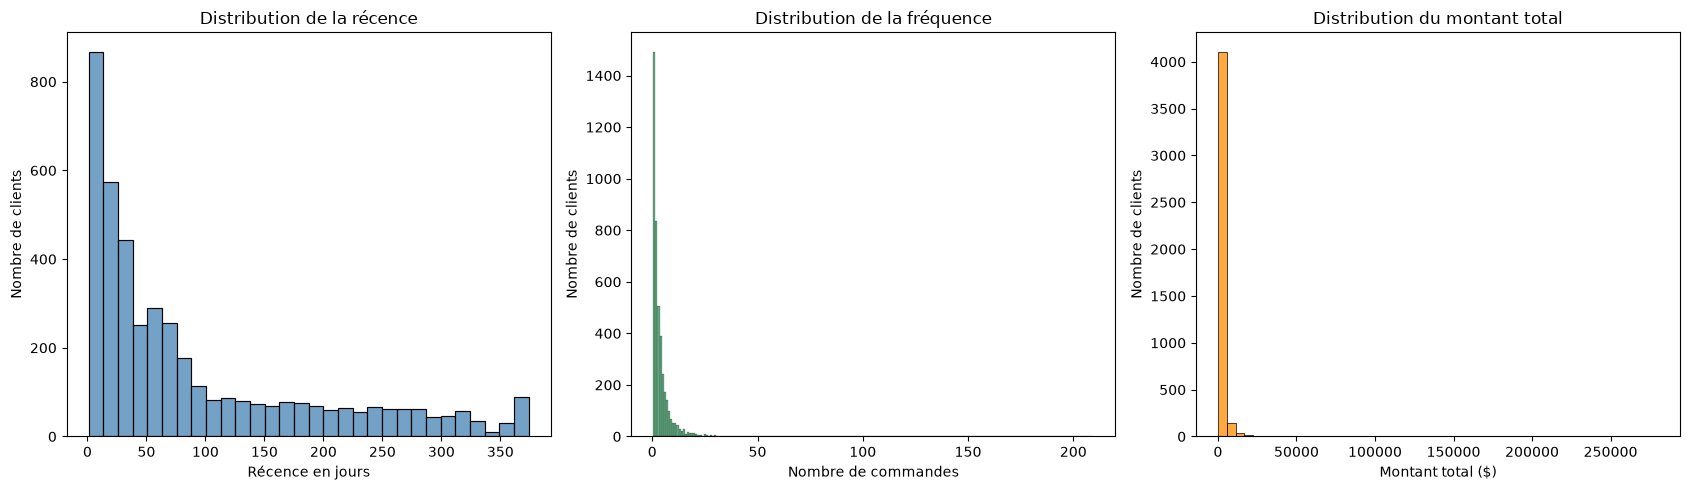

In [20]:
# Créer trois graphiques côte à côte
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Récence : regrouper les jours en intervalles
sns.histplot(
    data=rfm,
    x="recence",
    bins=30,
    color="steelblue",
    ax=axes[0]
)
axes[0].set_title("Distribution de la récence")
axes[0].set_xlabel("Récence en jours")

# Fréquence : une barre par nombre entier de commandes
sns.histplot(
    data=rfm,
    x="frequence",
    discrete=True,
    color="seagreen",
    ax=axes[1]
)
axes[1].set_title("Distribution de la fréquence")
axes[1].set_xlabel("Nombre de commandes")

# Montant : conserver toute l'étendue des achats observés
sns.histplot(
    data=rfm,
    x="montant_total",
    bins=50,
    color="darkorange",
    ax=axes[2]
)
axes[2].set_title("Distribution du montant total")
axes[2].set_xlabel("Montant total ($)")

# Harmoniser les libellés et la mise en page
for ax in axes:
    ax.set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

### 📊 Distribution des indicateurs RFM

Ils confirment une concentration vers les petites valeurs et une extension vers la droite, particulièrement marquée pour la fréquence et le montant.

| Indicateur | Lecture du graphique | Interprétation métier |
| :--- | :--- | :--- |
| **Récence** | Beaucoup de clients dans les premiers intervalles, puis des valeurs jusqu’à 374 jours | De nombreux clients ont acheté récemment ; d’autres n’ont pas acheté depuis plusieurs mois. |
| **Fréquence** | Forte concentration sur les premières commandes, avec une longue queue vers la droite | La plupart des clients commandent peu ; quelques-uns commandent beaucoup plus souvent. |
| **Montant** | Une première barre très haute et quelques valeurs très éloignées | Les grands montants étendent l’axe et compriment visuellement les autres profils. |

---

💡 **Remarque d’analyse :**  
La grande barre du montant ne représente pas uniquement des montants proches de zéro. Avec **50 intervalles** jusqu’à environ **280 206**, chaque barre couvre environ **5 604 unités monétaires**. La première regroupe donc une plage assez large d’achats.

La première barre de l’histogramme des montants couvre un intervalle large : elle ne signifie pas que tous les clients concernés
ont dépensé un montant proche de zéro.

Ces observations justifient l’étude d’une transformation logarithmique pour réduire l’asymétrie avant le clustering.

Les valeurs extrêmes ne sont pas automatiquement des erreurs. Nous allons les examiner avec des boxplots avant de décider
de leur traitement.

## 4.3 : Examen des valeurs extrêmes par boxplots

### Question métier

Certains clients présentent-ils des comportements très éloignés
du centre des distributions RFM ?

### Méthode

Construire un boxplot pour chacun des trois indicateurs,
dans ses unités d’origine.

Les points au-delà des moustaches signalent des valeurs atypiques
selon la règle de l’IQR. Ils ne prouvent pas une erreur.


### 📦 Comprendre le Boxplot (Boîte à moustaches)

Un boxplot, ou boîte à moustaches, résume une distribution :

| Élément | Signification |
| :--- | :--- |
| **Boîte** | Les 50 % centraux des valeurs, entre le 1er quartile ($Q_1$) et le 3e quartile ($Q_3$) |
| **Trait dans la boîte** | La médiane ($Q_2$) |
| **Moustaches** | S’étendent jusqu’aux dernières valeurs situées dans les bornes de la règle IQR |
| **Points au-delà** | Valeurs atypiques (*outliers*) selon cette règle ; pas nécessairement des erreurs |

---

💡 **Règle de l’Écart Interquartile (IQR) :**
$$\text{IQR} = Q_3 - Q_1$$

Les bornes habituelles pour détecter les valeurs atypiques sont :
* **Borne inférieure :** $Q_1 - 1{,}5 \times \text{IQR}$
* **Borne supérieure :** $Q_3 + 1{,}5 \times \text{IQR}$

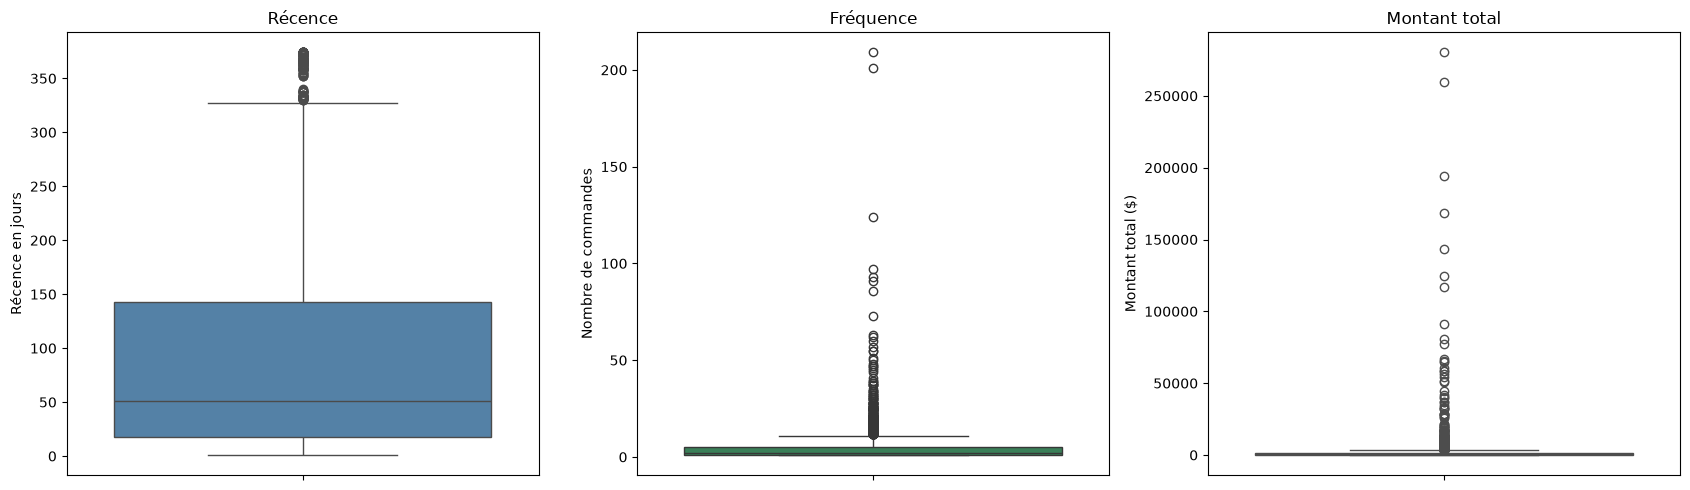

In [21]:
# Créer un boxplot séparé pour chaque indicateur
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.boxplot(data=rfm, y="recence", color="steelblue", ax=axes[0])
axes[0].set_title("Récence")
axes[0].set_ylabel("Récence en jours")

sns.boxplot(data=rfm, y="frequence", color="seagreen", ax=axes[1])
axes[1].set_title("Fréquence")
axes[1].set_ylabel("Nombre de commandes")

sns.boxplot(data=rfm, y="montant_total", color="darkorange", ax=axes[2])
axes[2].set_title("Montant total")
axes[2].set_ylabel("Montant total ($)")

plt.tight_layout()
plt.show()

### 📊 Analyse des Boxplots (Valeurs atypiques RFM)

Les boxplots confirment des valeurs atypiques, surtout pour la **fréquence** et le **montant**. Cela ne signifie pas que ces clients sont des erreurs : ils peuvent simplement avoir des comportements d’achat particuliers.

| Variable | Lecture du boxplot | Sens métier |
| :--- | :--- | :--- |
| **Récence** | Médiane à **51 jours** ; quelques points au-delà de la moustache supérieure | Certains clients n’ont pas acheté depuis presque un an. |
| **Fréquence** | Boîte concentrée entre **1 et 5 commandes** ; points jusqu’à **209** | Quelques clients commandent beaucoup plus souvent que les autres. |
| **Montant** | Boîte visuellement comprimée en bas ; points jusqu’à **280 206,02** | Certains clients présentent des montants très élevés. |

---

💡 **Remarques d'interprétation :**

* **Pourquoi la boîte du montant semble-t-elle presque invisible ?**  
  Elle représente les 50 % centraux des clients (entre **306,48** et **1 660,60**), alors que l’axe monte jusqu’à environ **280 000**. Les très grandes valeurs compriment donc visuellement la boîte.
* **Superposition des points :**  
  Les points au-delà des moustaches peuvent se chevaucher ; il n'est donc pas possible de compter précisément le nombre de clients atypiques à partir du seul graphique.
  
**Nous allons quantifier les valeurs situées au-delà des bornes IQR.**

### Quantification des valeurs atypiques par la méthode IQR

Pour chaque indicateur :

- IQR = Q3 − Q1
- Borne inférieure = Q1 − 1,5 × IQR
- Borne supérieure = Q3 + 1,5 × IQR

Les valeurs strictement en dehors de ces bornes sont signalées comme atypiques selon cette règle.

In [22]:
# Sélectionner les trois indicateurs, sans l'identifiant client
variables_rfm = ["recence", "frequence", "montant_total"]

# Observer les profils avant le diagnostic
display(rfm[["id_client"] + variables_rfm].head())

bilan_iqr = []

for variable in variables_rfm:
    valeurs = rfm[variable]

    # Calculer les quartiles et l'écart interquartile
    q1 = valeurs.quantile(0.25)
    q3 = valeurs.quantile(0.75)
    iqr = q3 - q1

    # Définir les bornes statistiques
    borne_inf = q1 - 1.5 * iqr
    borne_sup = q3 + 1.5 * iqr

    # Repérer les clients situés en dehors des bornes
    masque_atypique = (
        (valeurs < borne_inf) | (valeurs > borne_sup)
    )

    bilan_iqr.append({
        "variable": variable,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "borne_inferieure": borne_inf,
        "borne_superieure": borne_sup,
        "clients_atypiques": int(masque_atypique.sum()),
        "pourcentage": masque_atypique.mean() * 100
    })

# Présenter le diagnostic sans modifier les profils
tableau_iqr = pd.DataFrame(bilan_iqr).set_index("variable")
display(tableau_iqr.round(2))

,id_client,recence,frequence,montant_total
0,12346.0,326,1,77183.60
1,12347.0,3,7,4310.00
2,12348.0,76,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,311,1,334.40


,q1,q3,iqr,borne_inferieure,borne_superieure,clients_atypiques,pourcentage
variable,,,,,,,
recence,18.00,142.75,124.75,-169.12,329.88,155,3.57
frequence,1.00,5.00,4.00,-5.00,11.00,285,6.57
montant_total,306.48,1660.60,1354.11,-1724.69,3691.77,425,9.80


### 🔍 Diagnostic des valeurs atypiques (Méthode IQR)

Le diagnostic est cohérent : le **montant** présente la plus forte proportion de valeurs atypiques, avec **425 clients** (soit **9,80 %**). Nous allons **conserver ces profils à ce stade**, car la règle IQR signale des valeurs inhabituelles sans prouver qu’elles sont erronées.

| Indicateur | Borne supérieure affichée | Clients concernés | Lecture métier |
| :--- | :---: | :---: | :--- |
| **Récence** | 329,88 jours | **155** (3,57 %) | Dernier achat datant d’au moins 330 jours |
| **Fréquence** | 11 commandes | **285** (6,57 %) | Au moins 12 commandes sur la période |
| **Montant total** | 3 691,77 | **425** (9,80 %) | Montants supérieurs au seuil IQR calculé |

---

💡 **Remarques méthodologiques :**

* **Bornes inférieures :** Les bornes inférieures calculées sont négatives, alors que nos trois indicateurs sont strictement positifs. Tous les cas signalés se trouvent donc exclusivement au-dessus des bornes supérieures.
* **Non-cumul des effectifs :** La somme $155 + 285 + 425$ ne donne pas le total des clients atypiques distincts, car un même client peut dépasser plusieurs seuils simultanément.
* **Précision :** Les bornes dans le tableau ci-dessus sont arrondies pour la lisibilité ; le code utilise leur précision mathématique complète.
  
### Décision méthodologique

Nous conservons les 4 338 profils à ce stade. Aucune erreur n’a été démontrée par le seul diagnostic IQR.

Les récences élevées peuvent correspondre à des clients inactifs, tandis que les fréquences et montants élevés peuvent caractériser
des comportements d’achat importants pour la segmentation.

Nous étudierons la transformation logarithmique pour réduire l’influence des grandes valeurs sur les distances.

Cette transformation ne supprime pas les clients et ne garantit pas l’absence de valeurs atypiques après traitement.

### 4.4 : Relations entre les indicateurs RFM

### Questions métier

- Les clients qui commandent davantage dépensent-ils généralement plus ?
- Les clients ayant acheté récemment commandent-ils plus souvent ?
- Les trois indicateurs apportent-ils des informations complémentaires ?

### Méthode

Calculer les corrélations de Pearson et de Spearman
sur les trois indicateurs RFM.

Pearson mesure les relations linéaires entre les valeurs.
Spearman mesure les relations entre les rangs des clients.

Leur comparaison complète l’analyse de données asymétriques
contenant des valeurs extrêmes.

L’identifiant client est exclu des calculs.

Une corrélation mesure la manière dont deux variables évoluent ensemble. Nous comparerons deux approches complémentaires :

| Méthode | Ce qu’elle mesure | Pourquoi l’utiliser ici |
| :--- | :--- | :--- |
| **Pearson** | Relation linéaire entre les valeurs | Examiner les relations sur les indicateurs d’origine. |
| **Spearman** | Relation monotone basée sur le rang des clients | Compléter l’analyse avec une mesure robuste, moins sensible à l’amplitude des valeurs extrêmes. |

---

💡 **Rappel sur la corrélation :**
* La valeur oscille entre **$-1$** et **$+1$**.
* **Valeur positive :** Les variables évoluent dans le même sens.
* **Valeur négative :** Les variables évoluent en sens opposé.
* ⚠️ *Une corrélation mesure une association statistique et ne démontre pas de lien de causalité.*

,id_client,recence,frequence,montant_total
0,12346.0,326,1,77183.60
1,12347.0,3,7,4310.00
2,12348.0,76,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,311,1,334.40


Corrélations de Pearson :


,recence,frequence,montant_total
recence,1.00,-0.26,-0.12
frequence,-0.26,1.00,0.55
montant_total,-0.12,0.55,1.00



Corrélations de Spearman :


,recence,frequence,montant_total
recence,1.00,-0.56,-0.48
frequence,-0.56,1.00,0.81
montant_total,-0.48,0.81,1.00


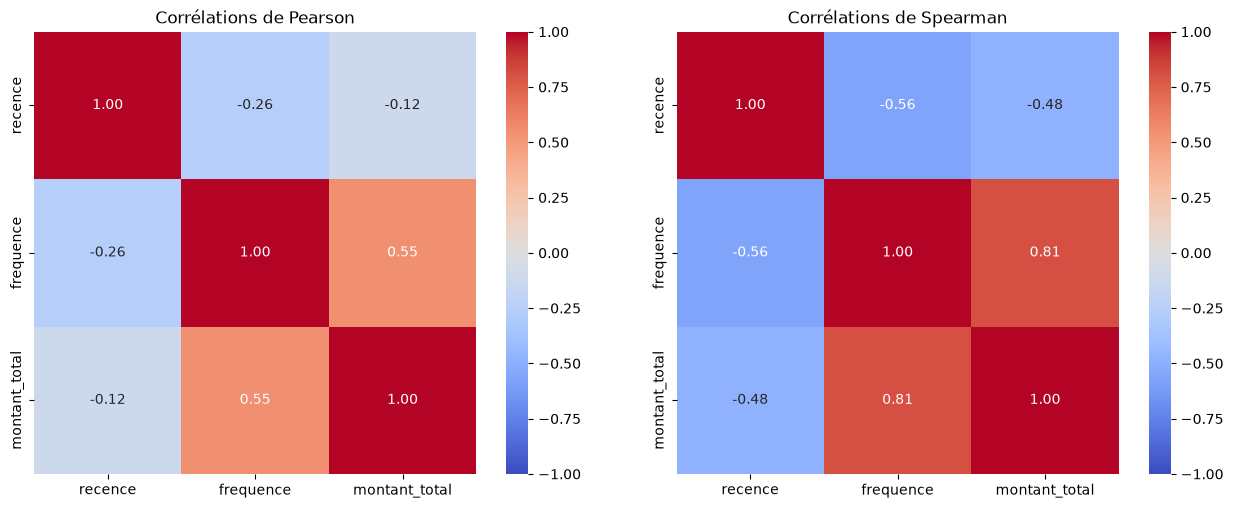

In [23]:
# Observer les profils utilisés pour l'analyse
display(rfm[["id_client"] + variables_rfm].head())

# Calculer les deux matrices de corrélation
correlation_pearson = rfm[variables_rfm].corr(method="pearson")
correlation_spearman = rfm[variables_rfm].corr(method="spearman")

# Afficher les valeurs
print("Corrélations de Pearson :")
display(correlation_pearson.round(2))

print("\nCorrélations de Spearman :")
display(correlation_spearman.round(2))

# Visualiser les deux matrices sur la même échelle
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, matrice, titre in [
    (axes[0], correlation_pearson, "Corrélations de Pearson"),
    (axes[1], correlation_spearman, "Corrélations de Spearman")
]:
    sns.heatmap(
        matrice,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        ax=ax
    )
    ax.set_title(titre)

plt.tight_layout()
plt.show()

### 📊 Analyse des matrices de corrélation (Pearson vs Spearman)

Les matrices montrent que les clients qui commandent davantage tendent à dépenser davantage et à avoir acheté plus récemment. Ces tendances sont plus nettement visibles avec Spearman qu’avec Pearson.

| Relation | Pearson | Spearman | Interprétation métier |
| :--- | :---: | :---: | :--- |
| **Fréquence ↔ Montant** | **0,55** | **0,81** | Les clients ayant davantage de commandes tendent à présenter un montant total plus élevé. |
| **Récence ↔ Fréquence** | **-0,26** | **-0,56** | Les clients ayant acheté plus récemment tendent à avoir davantage de commandes. |
| **Récence ↔ Montant** | **-0,12** | **-0,48** | Les clients ayant acheté plus récemment tendent à avoir un montant total plus élevé. |

> 💡 **Rappel d'interprétation :** Une faible récence correspond à un achat récent. Les coefficients négatifs associés à la récence traduisent donc une activité commerciale plus soutenue.

---

### 🔍 Pourquoi Pearson et Spearman donnent-ils des résultats différents ?

* **Pearson** étudie la relation strictement **linéaire** directe entre les valeurs réelles.
* **Spearman** évalue la relation monotone sur le **rang des clients**, sans être impacté par l’amplitude absolue des écarts.

*Exemple :* Deux clients peuvent être en haut du classement en termes de dépense, même si le premier dépense 10 fois plus que le second. Pearson subit cet écart d'amplitude, tandis que Spearman ne retient que leurs positions relatives.

> ⚠️ Cet écart entre les deux métriques est cohérent avec l'asymétrie de nos distributions et la présence de valeurs extrêmes.

#### Décision pour la segmentation

Nous conservons les trois indicateurs RFM :
- la récence décrit l’ancienneté du dernier achat ;
- la fréquence décrit la répétition des commandes ;
- le montant décrit le volume monétaire des achats retenus.

La fréquence et le montant sont fortement liés, mais apportent des informations métier différentes. Leur association devra
être prise en compte dans l’interprétation des clusters et de la PCA.

## 4.5 : Synthèse de l’exploration RFM

L’exploration des 4 338 profils montre :
- des distributions asymétriques vers les grandes valeurs ;
- des valeurs atypiques, particulièrement sur la fréquence et le montant ;
- une forte association entre les rangs de fréquence et de montant ;
- des associations négatives de la récence avec la fréquence et le montant.

Nous conservons les clients à ce stade :
les diagnostics statistiques ne prouvent pas des erreurs de données.

La prochaine étape consiste à tester une transformation logarithmique,
puis à standardiser les variables.

Nous comparerons les distributions avant et après transformation.
Les valeurs RFM d’origine seront conservées pour le profilage métier
et le dashboard Data Studio.

# Étape 5 : Prétraitement des variables RFM

## Objectif

Préparer les indicateurs RFM pour calculer des distances
entre clients sur des variables moins asymétriques
et sur des échelles comparables.

## Justification

L’exploration a montré :
- une asymétrie vers les grandes valeurs ;
- des fréquences et des montants particulièrement élevés
  pour certains clients ;
- des unités et des amplitudes différentes entre les indicateurs.

## Démarche

1. Appliquer la transformation logarithmique `np.log1p`.
2. Comparer les distributions et l’asymétrie avant et après.
3. Standardiser les variables transformées.
4. Vérifier les données préparées.

## 5.1 : Transformation logarithmique des indicateurs RFM

### Question d’analyse

La transformation logarithmique réduit-elle l’asymétrie
des distributions sans supprimer les profils clients ?

### Principe

`np.log1p(x)` calcule `ln(1 + x)`.

La transformation comprime les grandes valeurs
tout en conservant l’ordre des valeurs de chaque indicateur.

Nous la ferons sur :
- `recence` ;
- `frequence` ;
- `montant_total`.

### Organisation des données

- `rfm` conserve les valeurs d’origine.
- `rfm_log` contient uniquement les trois indicateurs transformés,dans le même ordre de lignes.

L’identifiant client est exclu de la transformation.

Les valeurs transformées ne s’interprètent plus directement
dans les unités d’origine.

In [24]:
# Définir les indicateurs dans un ordre fixe
variables_rfm = ["recence", "frequence", "montant_total"]

# Observer les profils avant transformation
print("Profils RFM d'origine :")
display(rfm[["id_client"] + variables_rfm].head())

# Créer un nouveau tableau avec les valeurs logarithmiques
rfm_log = np.log1p(rfm[variables_rfm])

# Observer les mêmes lignes après transformation
print("\nIndicateurs après np.log1p :")
display(rfm_log.head().round(3))

# Vérifier les dimensions et la validité numérique
print("\nDimensions :", rfm_log.shape)
print("Même ordre de lignes :", rfm_log.index.equals(rfm.index))
print("Toutes les valeurs sont finies :", np.isfinite(rfm_log).all().all())

Profils RFM d'origine :


,id_client,recence,frequence,montant_total
0,12346.0,326,1,77183.60
1,12347.0,3,7,4310.00
2,12348.0,76,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,311,1,334.40



Indicateurs après np.log1p :


,recence,frequence,montant_total
0,5.790,0.693,11.254
1,1.386,2.079,8.369
2,4.344,1.609,7.495
3,2.996,0.693,7.472
4,5.743,0.693,5.815



Dimensions : (4338, 3)
Même ordre de lignes : True
Toutes les valeurs sont finies : True


### Évaluation de la transformation

Nous comparons :
- les histogrammes avant et après transformation ;
- le coefficient d’asymétrie calculé avec `skew()`.

Un coefficient positif indique une asymétrie vers les grandes valeurs.
Un coefficient négatif indique une asymétrie vers les petites valeurs.

Une valeur plus proche de zéro indique une asymétrie moins marquée
selon cette mesure, sans prouver une distribution normale.

Nous conservons tous les clients et vérifions le résultat
avant de retenir le prétraitement pour le clustering.

,avant_log,apres_log
recence,1.246,-0.327
frequence,12.067,1.209
montant_total,19.339,0.397


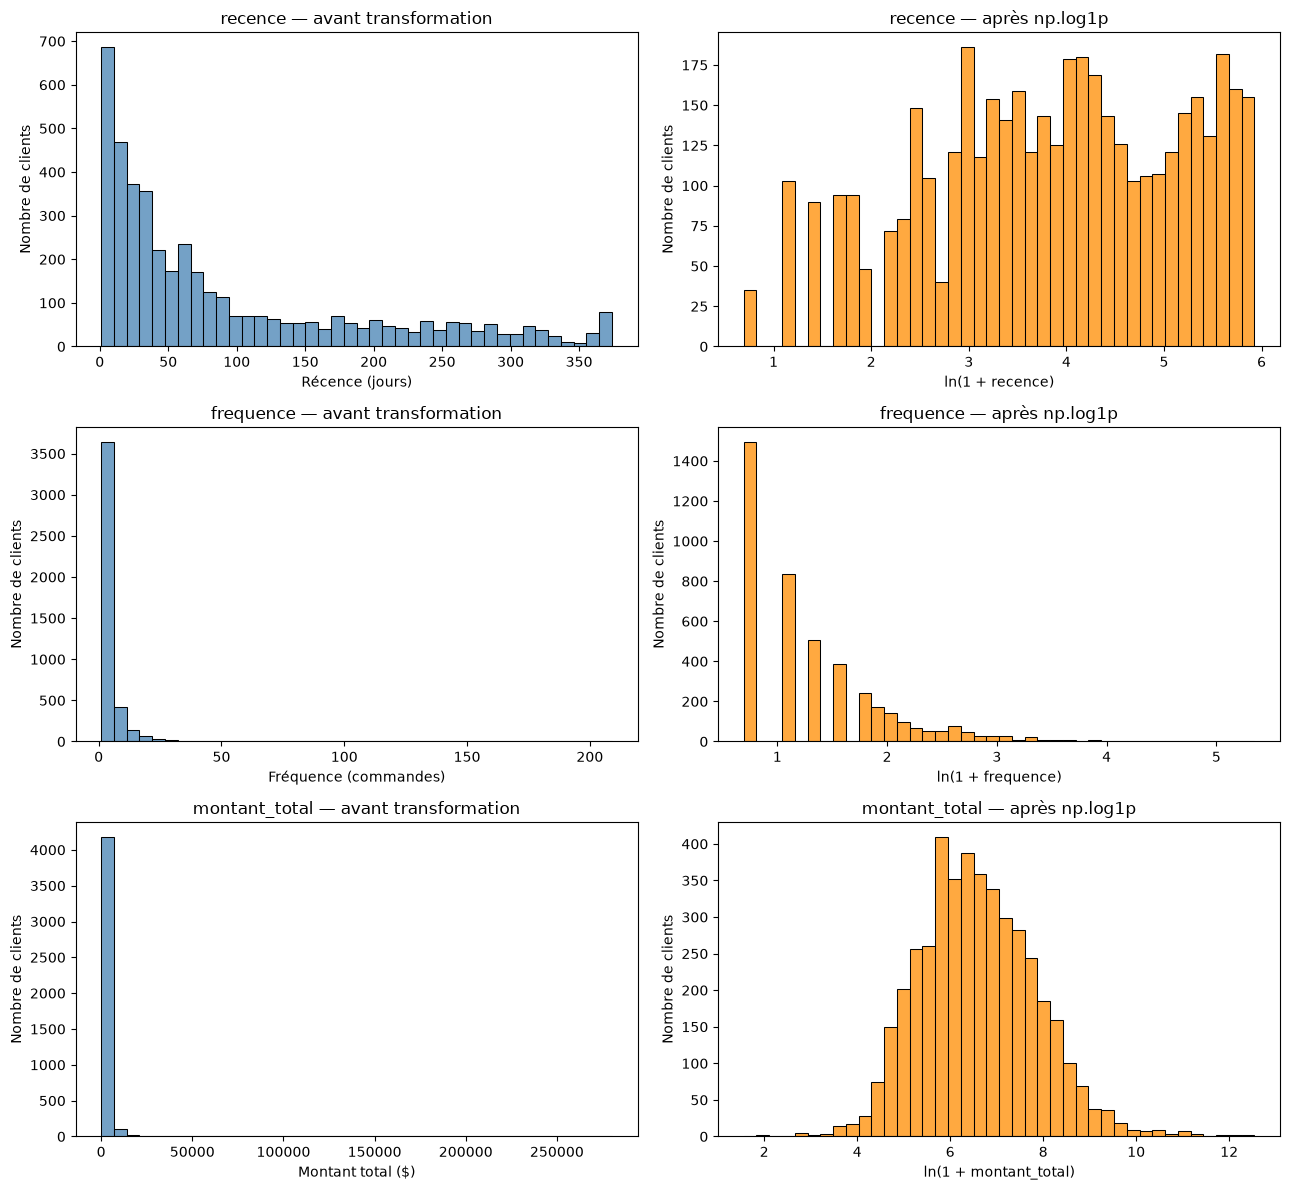

In [25]:
# Comparer l'asymétrie des trois indicateurs
comparaison_asymetrie = pd.DataFrame({
    "avant_log": rfm[variables_rfm].skew(),
    "apres_log": rfm_log.skew()
})

display(comparaison_asymetrie.round(3))

# Une ligne par indicateur :
# à gauche les valeurs d'origine, à droite les valeurs transformées
fig, axes = plt.subplots(3, 2, figsize=(13, 12))

libelles = {
    "recence": "Récence (jours)",
    "frequence": "Fréquence (commandes)",
    "montant_total": "Montant total ($)"
}

for i, variable in enumerate(variables_rfm):
    sns.histplot(
        x=rfm[variable],
        bins=40,
        color="steelblue",
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"{variable} — avant transformation")
    axes[i, 0].set_xlabel(libelles[variable])

    sns.histplot(
        x=rfm_log[variable],
        bins=40,
        color="darkorange",
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"{variable} — après np.log1p")
    axes[i, 1].set_xlabel(f"ln(1 + {variable})")

    for ax in axes[i]:
        ax.set_ylabel("Nombre de clients")

plt.tight_layout()
plt.show()

### Interprétation des distributions après transformation

La transformation `np.log1p` comprime les grandes valeurs
tout en conservant les 4 338 profils et leur ordre.

- **Récence :** la longue extension vers les grandes valeurs
  est comprimée. La distribution reste irrégulière.
- **Fréquence :** les petites fréquences restent dominantes,
  mais les écarts avec les clients commandant beaucoup sont réduits.
- **Montant total :** la distribution devient nettement moins
  asymétrique visuellement et présente une forme approximativement
  en cloche.

Les espaces visibles dans la fréquence transformée proviennent
de son caractère discret : le nombre de commandes est entier.

La transformation ne garantit ni une distribution normale
ni l’absence de valeurs atypiques.

Le tableau d’asymétrie permettra de compléter ces observations
par une comparaison chiffrée.

In [26]:
# Comparer l'asymétrie avant et après transformation
comparaison_asymetrie = pd.DataFrame({
    "avant_log": rfm[variables_rfm].skew(),
    "apres_log": rfm_log.skew()
})

display(comparaison_asymetrie.round(3))

,avant_log,apres_log
recence,1.246,-0.327
frequence,12.067,1.209
montant_total,19.339,0.397


### Évaluation et décision sur la transformation logarithmique

| Indicateur | Asymétrie avant | Asymétrie après |
|---|---:|---:|
| Récence | 1,246 | −0,327 |
| Fréquence | 12,067 | 1,209 |
| Montant total | 19,339 | 0,397 |

La valeur absolue du coefficient d’asymétrie diminue
pour les trois indicateurs.

L’amélioration est particulièrement importante pour la fréquence
et le montant. La fréquence reste asymétrique vers les grandes valeurs.

Nous retenons `np.log1p` sur les trois indicateurs pour poursuivre
la segmentation, en conservant les 4 338 clients.

Cette transformation ne garantit pas une distribution normale
ni une segmentation optimale.

Les valeurs d’origine restent disponibles dans `rfm`.
Les valeurs transformées sont conservées dans `rfm_log`.

## 5.2 : Standardisation des variables logarithmiques

### Question d’analyse

Comment rendre les échelles des trois indicateurs comparables
pour le calcul des distances entre clients ?

### Méthode

Nous appliquons `StandardScaler` aux variables de `rfm_log`.

Pour chaque colonne, le scaler soustrait sa moyenne
et divise par son écart-type.

Les variables obtenues ont une moyenne proche de zéro
et un écart-type proche de un.

### Organisation des données

- `rfm` : valeurs RFM d’origine pour l’interprétation métier.
- `rfm_log` : valeurs après transformation logarithmique.
- `X_scaled` : valeurs logarithmiques standardisées pour le clustering.

In [27]:
from sklearn.preprocessing import StandardScaler

# Observer les variables avant standardisation
print("Avant standardisation :")
display(rfm_log.head().round(3))

# Créer le scaler et apprendre les moyennes et écarts-types
scaler = StandardScaler()
scaler.fit(rfm_log)

# Transformer les profils avec les paramètres appris
valeurs_standardisees = scaler.transform(rfm_log)

# Conserver les noms des colonnes et l'ordre des clients
X_scaled = pd.DataFrame(
    valeurs_standardisees,
    columns=rfm_log.columns,
    index=rfm_log.index
)

print("\nAprès standardisation :")
display(X_scaled.head().round(3))

# Vérifier le centrage et l'échelle
bilan_standardisation = pd.DataFrame({
    "moyenne": X_scaled.mean(),
    "ecart_type": X_scaled.std(ddof=0)
})

display(bilan_standardisation.round(6))
print("Dimensions :", X_scaled.shape)

Avant standardisation :


,recence,frequence,montant_total
0,5.790,0.693,11.254
1,1.386,2.079,8.369
2,4.344,1.609,7.495
3,2.996,0.693,7.472
4,5.743,0.693,5.815



Après standardisation :


,recence,frequence,montant_total
0,1.479,-0.955,3.708
1,-1.891,1.074,1.415
2,0.372,0.386,0.720
3,-0.659,-0.955,0.702
4,1.443,-0.955,-0.615


,moyenne,ecart_type
recence,0.0,1.0
frequence,-0.0,1.0
montant_total,-0.0,1.0


Dimensions : (4338, 3)


### Validation de la standardisation

Les trois variables standardisées présentent :
- une moyenne proche de **0** ;
- un écart-type de **1**

Le tableau `X_scaled` contient **4 338 lignes et 3 colonnes**.
Tous les profils ont été conservés.

Les valeurs négatives indiquent une position sous la moyenne
de la variable logarithmique, et non des achats négatifs.La standardisation rend les échelles comparables.

## 5.3 : Contrôles finaux du prétraitement

### Objectif

Vérifier que les données destinées au clustering sont complètes,
numériques et correctement alignées avec les profils d’origine.

### Contrôles

- Même nombre de profils avant et après prétraitement.
- Même ordre de lignes.
- Présence des trois indicateurs dans l’ordre prévu.
- Absence de valeurs manquantes ou infinies.
- Moyennes proches de zéro et écarts-types proches de un.

In [28]:
# Vérifier les données préparées pour le clustering
controles_pretraitement = pd.Series({
    "Même nombre de profils": len(X_scaled) == len(rfm),
    "Même ordre de lignes": X_scaled.index.equals(rfm.index),
    "Trois indicateurs dans le bon ordre": (
        X_scaled.columns.tolist() == variables_rfm
    ),
    "Colonnes toutes numériques": all(
        pd.api.types.is_numeric_dtype(X_scaled[colonne])
        for colonne in X_scaled.columns
    ),
    "Aucune valeur manquante": not X_scaled.isna().any().any(),
    "Toutes les valeurs sont finies": (
        np.isfinite(X_scaled.to_numpy()).all()
    ),
    "Moyennes proches de zéro": np.allclose(
        X_scaled.mean(), 0, atol=1e-10
    ),
    "Écarts-types proches de un": np.allclose(
        X_scaled.std(ddof=0), 1, atol=1e-10
    )
}, name="controle_valide")

display(controles_pretraitement.to_frame())

,controle_valide
Même nombre de profils,True
Même ordre de lignes,True
Trois indicateurs dans le bon ordre,True
Colonnes toutes numériques,True
Aucune valeur manquante,True
Toutes les valeurs sont finies,True
Moyennes proches de zéro,True
Écarts-types proches de un,True


### Synthèse du prétraitement

Nous avons préparé les trois indicateurs RFM en deux opérations :

1. **Transformation logarithmique**
   Réduction de l’asymétrie et compression des grandes valeurs.

2. **Standardisation**
   Centrage et mise à l’échelle des variables logarithmiques.

Les données sont conservées dans trois tableaux :
- `rfm` : valeurs d’origine pour l’interprétation métier ;
- `rfm_log` : valeurs logarithmiques ;
- `X_scaled` : valeurs utilisées pour le clustering et la PCA.

Le scaler ajusté est conservé pour appliquer le même prétraitement à de nouveaux profils.

## Étape 6 : Segmentation par K-Means

## Objectif

Identifier des groupes de clients présentant des profils RFM similaires.

## Question métier

Combien de segments permettent de résumer les comportements d’achat
tout en restant exploitables par les équipes marketing ?

## Données utilisées

Le clustering utilise `X_scaled`, contenant les trois indicateurs
logarithmiques standardisés pour les 4 338 clients.

L’identifiant client est exclu du calcul des distances.

## Démarche

1. Comparer plusieurs valeurs de K.
2. Examiner la courbe du coude et le score de silhouette.
3. Étudier les effectifs et les profils pour les valeurs candidates.
4. Retenir une segmentation justifiée statistiquement et métier.
5. Entraîner le modèle retenu et interpréter les groupes.



### 1. Principes du K-Means et choix du nombre de clusters ($K$)

* **Définition :** $K$ représente le nombre de groupes demandé à l’algorithme (par exemple, pour $K = 3$, l'algorithme répartit la base client en 3 clusters).
* **Centroïde :** Chaque groupe possède un centroïde, c’est-à-dire le point central dans l’espace à 3 dimensions (RFM standardisé). K-Means cherche à minimiser la somme des distances au carré entre chaque client et le centroïde de son groupe.

| Nombre de groupes | Avantage | Risque |
| :--- | :--- | :--- |
| **Petit $K$** | Segmentation synthétique et facile à exploiter | Risque de regrouper des comportements trop différents |
| **Grand $K$** | Profils plus précis et ciblés | Multiplication de micro-segments difficiles à animer en marketing |

---

### 2. Indicateurs d'évaluation de la qualité des clusters

Pour évaluer la pertinence statistique de chaque découpage, nous suivons deux métriques :

| Indicateur | Ce qu’il mesure | Lecture & Interprétation |
| :--- | :--- | :--- |
| **Inertie** | Somme des distances au carré entre les clients et leur centroïde | Rechercher un **« coude »** sur la courbe, marquant le point d'inflexion du gain de cohérence. |
| **Score de Silhouette** | Proximité d’un client avec son groupe comparé au groupe le plus proche | Un score moyen plus élevé indique une meilleure séparation des clusters. |

---

💡 **Rappels méthodologiques :**

* **Plage du score de Silhouette ($-1$ à $+1$) :**
  * **Proche de $+1$ :** Les groupes sont nettement séparés et bien définis.
  * **Proche de $0$ :** Les points se situent sur la frontière entre deux clusters.
  * **Négatif :** L'affectation de certains profils manque de cohérence géométrique.
* ⚠️ **Attention :** Une baisse d'inertie seule ne garantit pas une meilleure segmentation, car l'inertie diminue mécaniquement à mesure que $K$ augmente.

## 6.1 : Comparaison du nombre de clusters

### Méthode

Nous testons les valeurs de K de 2 à 10.

Pour chaque valeur, nous calculons :
- l’inertie ;
- le score moyen de silhouette sur les 4 338 clients ;
- l’effectif du plus petit et du plus grand cluster.

Les modèles utilisent les mêmes données et paramètres,
à l’exception du nombre de clusters.

Nous fixons :
- `random_state=42` pour rendre l’exécution reproductible ;
- `n_init=10` pour comparer dix initialisations et conserver
  celle présentant la plus faible inertie.

Le choix final ne sera pas automatique :
les indicateurs seront confrontés aux profils et à leur utilité métier.

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Observer les données utilisées pour le clustering
display(X_scaled.head())

resultats_k = []
modeles_k = {}

# Tester de 2 à 10 groupes
for k in range(2, 11):
    modele = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    # Apprendre les centres et attribuer un cluster à chaque client
    labels = modele.fit_predict(X_scaled)

    # Calculer la silhouette sur tous les profils préparés
    silhouette = silhouette_score(X_scaled, labels)

    # Compter les clients dans chaque cluster
    effectifs = pd.Series(labels).value_counts()

    resultats_k.append({
        "k": k,
        "inertie": modele.inertia_,
        "silhouette": silhouette,
        "plus_petit_cluster": effectifs.min(),
        "plus_grand_cluster": effectifs.max()
    })

    # Conserver le modèle pour examiner les candidats ensuite
    modeles_k[k] = modele

    print(f"K = {k} terminé — silhouette : {silhouette:.3f}")

# Présenter les résultats sans arrondir les valeurs stockées
comparaison_k = pd.DataFrame(resultats_k)
display(comparaison_k.round(3))

,recence,frequence,montant_total
0,1.478884,-0.955214,3.707716
1,-1.890642,1.074425,1.414903
2,0.372339,0.386304,0.720024
3,-0.659158,-0.955214,0.702287
4,1.442954,-0.955214,-0.614514


K = 2 terminé — silhouette : 0.433
K = 3 terminé — silhouette : 0.336


K = 4 terminé — silhouette : 0.333
K = 5 terminé — silhouette : 0.318


K = 6 terminé — silhouette : 0.313
K = 7 terminé — silhouette : 0.310


K = 8 terminé — silhouette : 0.302
K = 9 terminé — silhouette : 0.296


K = 10 terminé — silhouette : 0.277


,k,inertie,silhouette,plus_petit_cluster,plus_grand_cluster
0,2,6476.507,0.433,1668,2670
1,3,4858.244,0.336,775,1866
2,4,3925.426,0.333,718,1549
3,5,3269.275,0.318,365,1141
4,6,2841.417,0.313,343,948
5,7,2532.985,0.310,230,892
6,8,2325.075,0.302,217,848
7,9,2156.020,0.296,97,833
8,10,1989.405,0.277,92,638


### 📊 Évaluation des solutions K-Means (de K=2 à K=10)

**$K=2$** obtient le meilleur score de silhouette parmi l'ensemble des valeurs testées (**0,433**). C’est notre premier candidat. Nous le comparerons à **$K=3$** et **$K=4$** pour déterminer si un découpage plus fin apporte des distinctions métier réellement exploitables.

| $K$ | Silhouette | Taille min. | Taille max. | Lecture & Analyse |
| :---: | :---: | :---: | :---: | :--- |
| **2** | **0,433** | 1 668 | 2 670 | **Meilleure séparation moyenne** parmi les solutions testées. |
| **3** | **0,336** | 775 | 1 866 | Segmentation plus détaillée, mais baisse notable de la séparation. |
| **4** | **0,333** | 718 | 1 549 | Score très proche de $K=3$ ; profils métier à examiner. |
| **5 à 10** | **0,318 → 0,277** | 365 → 92 | 1 141 → 638 | Groupes plus nombreux sans amélioration du score de silhouette. |

---

💡 **Remarques d'interprétation :**

* **Évolution de l'inertie :** L’inertie totale diminue de **6 476,51** à **1 989,41** lorsque $K$ passe de 2 à 10. Il s'agit d'un comportement mécanique normal : ajouter des centroïdes rapproche nécessairement chaque client de son centre.
* **Absence de coude évident :** Bien que les gains d’inertie ralentissent au fil des itérations, les chiffres seuls ne révèlent pas de point d'inflexion (« coude ») imposant de manière indiscutable une valeur particulière.
* ⚠️ **Décision méthodologique :** Nous retenons **K=2 comme premier candidat statistique**.

Nous examinerons également **K=3 et K=4** pour déterminer si les groupes supplémentaires apportent des profils métier distincts et des actions marketing différentes.

Le choix final dépendra des profils RFM, des effectifs et de la stabilité des solutions candidates.

## 6.2 : Comparaison des profils pour K=2, K=3 et K=4

### Question métier

Les groupes supplémentaires permettent-ils de distinguer
des comportements nécessitant des actions marketing différentes ?

### Méthode

Pour chaque solution candidate, calculer :
- l’effectif et la part des clients par cluster ;
- les moyennes et médianes des trois indicateurs RFM ;
- le montant cumulé et sa part dans les achats retenus.

Les statistiques sont calculées sur les valeurs RFM d’origine.

Les modèles déjà entraînés sont réutilisés.
Les numéros de clusters ne correspondent pas nécessairement
entre les différentes solutions.

In [30]:
# Conserver les tableaux de profils pour les comparer ensuite
profils_candidats = {}

for k in [2, 3, 4]:
    # Créer un tableau temporaire sans modifier rfm
    clients_candidats = rfm.copy()

    # Ajouter les affectations du modèle déjà entraîné
    clients_candidats["cluster"] = modeles_k[k].labels_

    # Décrire les groupes dans les unités RFM d'origine
    profils = (
        clients_candidats.groupby("cluster")
        .agg(
            effectif=("id_client", "size"),
            recence_moyenne=("recence", "mean"),
            recence_mediane=("recence", "median"),
            frequence_moyenne=("frequence", "mean"),
            frequence_mediane=("frequence", "median"),
            montant_moyen=("montant_total", "mean"),
            montant_median=("montant_total", "median"),
            montant_cumule=("montant_total", "sum")
        )
    )

    # Calculer le poids de chaque groupe
    profils["part_clients_pct"] = (
        profils["effectif"] / len(rfm) * 100
    )

    profils["part_montant_pct"] = (
        profils["montant_cumule"] / rfm["montant_total"].sum() * 100
    )

    profils_candidats[k] = profils

    print(f"\nProfils des clusters pour K={k} :")
    display(profils.round(2))


Profils des clusters pour K=2 :


,effectif,recence_moyenne,recence_mediane,frequence_moyenne,frequence_mediane,montant_moyen,montant_median,montant_cumule,part_clients_pct,part_montant_pct
cluster,,,,,,,,,,
0,1668,26.45,17.0,8.44,6.0,4535.74,2058.17,7565611.80,38.45,85.13
1,2670,134.67,96.0,1.67,1.0,494.98,362.01,1321597.09,61.55,14.87



Profils des clusters pour K=3 :


,effectif,recence_moyenne,recence_mediane,frequence_moyenne,frequence_mediane,montant_moyen,montant_median,montant_cumule,part_clients_pct,part_montant_pct
cluster,,,,,,,,,,
0,775,17.97,10.0,13.31,10.0,7880.00,3701.44,6106996.99,17.87,68.72
1,1866,168.87,160.0,1.36,1.0,362.51,296.09,676449.08,43.02,7.61
2,1697,43.99,30.0,3.35,3.0,1239.70,962.19,2103762.82,39.12,23.67



Profils des clusters pour K=4 :


,effectif,recence_moyenne,recence_mediane,frequence_moyenne,frequence_mediane,montant_moyen,montant_median,montant_cumule,part_clients_pct,part_montant_pct
cluster,,,,,,,,,,
0,897,22.79,20.0,1.92,2.0,486.06,414.20,435999.12,20.68,4.91
1,1174,65.29,52.0,4.19,4.0,1822.98,1355.04,2140183.49,27.06,24.08
2,1549,192.27,187.0,1.35,1.0,360.55,303.16,558489.10,35.71,6.28
3,718,12.21,9.0,13.64,10.0,8011.89,3687.77,5752537.18,16.55,64.73


## 🎯 Synthèse et choix de la solution K-Means ($K=4$)

$K=4$ apporte une distinction métier utile en séparant les petits acheteurs récents des petits acheteurs anciens. Nous le retenons comme **candidat métier privilégié**, tout en gardant **$K=2$ comme référence statistique**.

---

### 1. Comparaison synthétique des segmentations

| Solution | Ce qu’elle apporte | Limite principale |
| :---: | :--- | :--- |
| **$K=2$** | Sépare nettement les clients actifs à forte contribution des clients moins actifs. | Le deuxième groupe reste très hétérogène et mélange plusieurs comportements. |
| **$K=3$** | Distingue forte activité, activité intermédiaire et achats anciens peu fréquents. | Les petits acheteurs récents ne forment pas encore un groupe clairement isolé. |
| **$K=4$** | **Distingue 4 profils distincts** pouvant justifier des actions marketing ciblées. | Score de silhouette ($0{,}333$) inférieur à celui de $K=2$ ($0{,}433$). |

> 💡 **Arbitrage :** $K=4$ n’est pas la meilleure solution sur le seul critère géométrique, mais elle apporte une granulométrie opérationnelle bien plus pertinente pour le ciblage.

---

### 2. Lecture détaillée des quatre profils ($K=4$)

*Les médianes représentent ici la valeur centrale caractérisant chaque groupe :*

| Cluster | Effectif (Share) | Récence médiane | Commandes médianes | Montant médian | Nom provisoire | Action marketing envisagée |
| :---: | :---: | :---: | :---: | :---: | :--- | :--- |
| **0** | 897 (20,68 %) | **20 jours** | **2** | **414,20 €** | **Acheteurs récents occasionnels** | Encourager la prochaine commande pour transformer l'essai. |
| **1** | 1 174 (27,06 %) | **52 jours** | **4** | **1 355,04 €** | **Acheteurs réguliers à entretenir** | Maintenir l’engagement et proposer des offres complémentaires. |
| **2** | 1 549 (35,71 %) | **187 jours** | **1** | **303,16 €** | **Acheteurs anciens peu fréquents** | Tester une campagne ciblée de réactivation / relance. |
| **3** | 718 (16,55 %) | **9 jours** | **10** | **3 687,77 €** | **Champions (forte activité)** | Fidéliser prioritairement et proposer un suivi dédié. |

---

### 3. Analyses complémentaires & Predictions métier

* **Concentration du CA (Cluster 3) :** Bien qu'il ne représente que **16,55 % des clients**, le Cluster 3 pèse pour **64,73 % du montant total retenu**. Il s'agit d'une très forte concentration de la valeur d'achat (à ne pas confondre directement avec la rentabilité nette).
* **Asymétrie résiduelle :** La moyenne du montant pour le Cluster 3 (**8 011,89 €**) dépasse largement sa médiane (**3 687,77 €**), prouvant que quelques acheteurs exceptionnels tirent encore les valeurs vers le haut.

⚠️ **Précautions d'interprétation métier :**
1. **Récence ≠ Ancienneté :** Un client « récent » signale uniquement la date de son *dernier* achat, et non la date de sa *première* commande (il ne s'agit pas nécessairement d'un nouveau client).
2. **Statut « À risque » :** Le Cluster 2 rassemble des clients inactifs depuis longtemps, mais cela ne prouve pas qu'ils étaient fidèles auparavant. L'étiquette « À risque d'attrition » reste donc une hypothèse à valider.

### Décision intermédiaire

Nous privilégions **K=4 comme candidat métier**,
malgré une silhouette de **0,333**, inférieure à celle de K=2.

Les noms des segments restent provisoires.
La stabilité des solutions candidates sera examinée
avant le choix final.

Les recommandations marketing constituent des hypothèses à tester,
et non des effets démontrés par le clustering.


## 6.3 : Stabilité des solutions selon l’initialisation

### Question d’analyse

Les regroupements changent-ils lorsque K-Means démarre
avec des initialisations différentes ?

### Méthode

Pour K=2, K=3 et K=4 :
- réentraîner K-Means avec cinq graines aléatoires différentes ;
- conserver `n_init=10` et les mêmes données ;
- comparer chaque regroupement au modèle de référence avec l’ARI.

L’ARI compare les appartenances aux groupes,
indépendamment de leurs numéros.

Ce contrôle examine la stabilité face à l’initialisation.
Il ne mesure pas la stabilité dans le temps ou sur d’autres données.
Une segmentation est **stable par rapport à l’initialisation** si plusieurs exécutions successives de l'algorithme retrouvent pratiquement les mêmes groupes.

Pour mesurer cette stabilité, nous utiliserons l’**ARI** (*Adjusted Rand Index*), un score de comparaison entre deux découpages qui s'affranchit du numérotage arbitraire des clusters :

| Score ARI | Lecture & Interprétation |
| :---: | :--- |
| **$1{,}00$** | **Regroupements identiques** (accord parfait), même si les étiquettes/numéros changent. |
| **Proche de $0$** | Accord faible, similaire à une attribution obtenue **par hasard**. |
| **Négatif** | Accord plus faible que ce que le hasard produirait. |

In [31]:
from sklearn.metrics import adjusted_rand_score

resultats_stabilite = []

for k in [2, 3, 4]:
    # Regroupement de référence obtenu avec random_state=42
    labels_reference = modeles_k[k].labels_

    for graine in [0, 1, 2, 3, 4]:
        modele_test = KMeans(
            n_clusters=k,
            init="k-means++",
            n_init=10,
            random_state=graine
        )

        labels_test = modele_test.fit_predict(X_scaled)

        resultats_stabilite.append({
            "k": k,
            "graine": graine,
            "ari_reference": adjusted_rand_score(
                labels_reference, labels_test
            ),
            "inertie": modele_test.inertia_
        })

stabilite_k = pd.DataFrame(resultats_stabilite)

# Résumer les cinq comparaisons pour chaque K
resume_stabilite = (
    stabilite_k.groupby("k")
    .agg(
        ari_moyen=("ari_reference", "mean"),
        ari_minimum=("ari_reference", "min"),
        inertie_minimum=("inertie", "min"),
        inertie_maximum=("inertie", "max")
    )
)

display(resume_stabilite.round(4))

,ari_moyen,ari_minimum,inertie_minimum,inertie_maximum
k,,,,
2,0.9998,0.9991,6476.5069,6476.5233
3,0.9841,0.9792,4858.0534,4858.2099
4,0.9611,0.8949,3925.0468,3925.5395


###  Analyse de la stabilité de l'initialisation (ARI)

Les trois solutions sont globalement très stables face à l’initialisation des centroïdes. Bien que $K=4$ montre une variabilité légèrement plus élevée que $K=2$ et $K=3$, nous le **retenons pour la suite du projet** en raison de la pertinence des quatre profils métier identifiés, tout en documentant cette limite.

### Résultats de stabilité

Les cinq essais par valeur de K montrent :
- une stabilité presque parfaite pour K=2 ;
- une forte stabilité pour K=3 ;
- une forte concordance moyenne pour K=4,
  avec une variation plus importante sur un essai.

Pour K=4, l’ARI moyen est de **0,9611**
et l’ARI minimum de **0,8949**.

Les inerties sont proches entre les essais.Une inertie similaire ne garantit toutefois pas des affectations identiques.

### Choix retenu pour le projet

Nous retenons **K=4** pour poursuivre l’analyse.

Ce choix repose sur les profils métier :
- acheteurs récents occasionnels ;
- acheteurs réguliers à entretenir ;
- acheteurs anciens peu fréquents ;
- clients à forte activité.

K=2 conserve la meilleure silhouette et la plus forte stabilité,
mais fournit une segmentation moins détaillée.

### Limites

La solution à quatre groupes est moins stable que les solutions à deux ou trois groupes face aux initialisations testées.

Ce contrôle ne démontre ni la stabilité dans le temps ni l’efficacité des actions marketing proposées.

| $K$ | ARI moyen | ARI minimum | Interprétation & Cohérence |
| :---: | :---: | :---: | :--- |
| **2** | **0,9998** | **0,9991** | Regroupements pratiquement identiques entre tous les essais. |
| **3** | **0,9841** | **0,9792** | Très forte concordance avec le modèle de référence. |
| **4** | **0,9611** | **0,8949** | Forte concordance moyenne, mais présence d'un essai plus divergent. |

---

💡 **Remarques méthodologiques :**

* **Stabilité de l'inertie :** Les valeurs d'inertie restent extrêmement proches pour chaque $K$. Cela démontre que des configurations de regroupements légèrement différentes peuvent aboutir à une qualité géométrique (inertie) quasi identique.
* ⚠️ **Interprétation du score ARI :** Un ARI de **0,9611** ne signifie pas que **96,11 %** des clients conservent exactement leur cluster. L'ARI est un indice d'accord statistique ajusté pour le hasard, et non une proportion directe d'observations inchangées.

## 6.4 : Attribution des clusters retenus aux profils clients

### Objectif

Associer chaque client à l’un des quatre groupes retenus.

### Méthode

Conserver le modèle K-Means de référence pour K=4
et ajouter ses affectations à une copie du tableau RFM.

Le tableau enrichi est nommé `rfm_segments`.
Le tableau `rfm` conserve les indicateurs d’origine sans cluster.

Les numéros de clusters sont des identifiants :
ils ne représentent ni un classement ni une valeur commerciale.

In [32]:
# Conserver le modèle de référence déjà étudié
k_retenu = 4
modele_kmeans = modeles_k[k_retenu]

# Vérifier l'alignement avant d'ajouter les affectations
assert rfm.index.equals(X_scaled.index), (
    "L'ordre des profils RFM et des données préparées doit être identique."
)

# Observer les profils avant attribution
display(rfm.head())

# Créer le tableau enrichi
rfm_segments = rfm.copy()
rfm_segments["cluster"] = modele_kmeans.labels_

# Observer les mêmes profils après attribution
display(rfm_segments.head())

# Vérifier les effectifs
effectifs_clusters = (
    rfm_segments["cluster"]
    .value_counts()
    .sort_index()
    .rename("nombre_clients")
)

display(effectifs_clusters.to_frame())

print("Dimensions :", rfm_segments.shape)
print("Total des clients :", effectifs_clusters.sum())

,id_client,recence,frequence,montant_total
0,12346.0,326,1,77183.60
1,12347.0,3,7,4310.00
2,12348.0,76,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,311,1,334.40


,id_client,recence,frequence,montant_total,cluster
0,12346.0,326,1,77183.60,1
1,12347.0,3,7,4310.00,3
2,12348.0,76,4,1797.24,1
3,12349.0,19,1,1757.55,0
4,12350.0,311,1,334.40,2


,nombre_clients
cluster,
0,897
1,1174
2,1549
3,718


Dimensions : (4338, 5)
Total des clients : 4338


## 6.5 : Visualisation des groupes dans les variables RFM

### Questions métier

- Comment les groupes se distinguent-ils selon la récence,
  la fréquence et le montant ?
- Les différences observées correspondent-elles aux profils calculés ?

### Méthode

Construire trois nuages de points :
1. récence et fréquence ;
2. récence et montant total ;
3. fréquence et montant total.

Les points représentent les clients et les couleurs leurs clusters.

Pour rendre les grandes amplitudes lisibles, les axes de fréquence
et de montant utilisent une échelle logarithmique.

Cette échelle modifie uniquement l’affichage.
Les valeurs RFM et les affectations aux clusters restent inchangées.

### Limite

Chaque graphique représente deux indicateurs à la fois,
alors que K-Means utilise les trois indicateurs préparés.

Un chevauchement dans ces graphiques ne suffit donc pas
à invalider la segmentation.

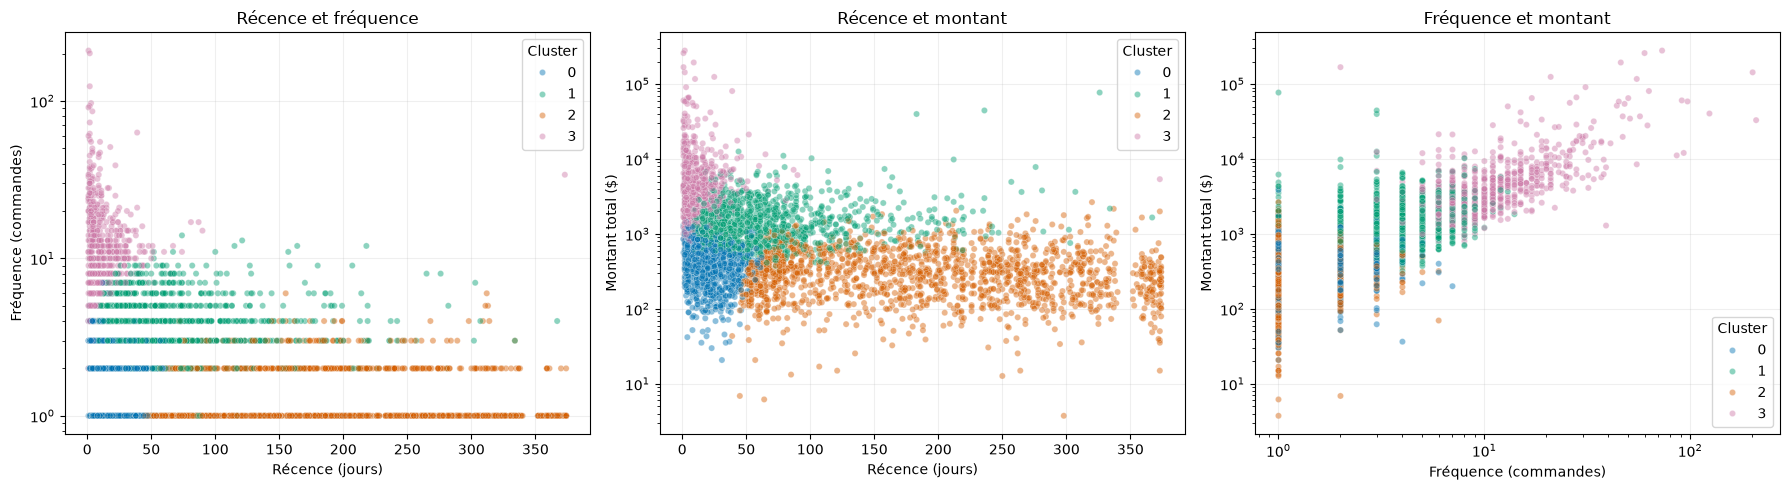

In [33]:
# Préparer une copie réservée aux graphiques
df_visualisation = rfm_segments.copy()

# Traiter les numéros comme des catégories pour la légende
df_visualisation["cluster"] = (
    df_visualisation["cluster"].astype(str)
)

# Conserver les mêmes couleurs sur tous les graphiques
couleurs_clusters = {
    "0": "#0072B2",
    "1": "#009E73",
    "2": "#D55E00",
    "3": "#CC79A7"
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Définir les trois paires d'indicateurs
configurations = [
    (
        "recence", "frequence",
        "Récence et fréquence",
        "Récence (jours)", "Fréquence (commandes)"
    ),
    (
        "recence", "montant_total",
        "Récence et montant",
        "Récence (jours)", "Montant total ($)"
    ),
    (
        "frequence", "montant_total",
        "Fréquence et montant",
        "Fréquence (commandes)", "Montant total ($)"
    )
]

for ax, (x, y, titre, libelle_x, libelle_y) in zip(
    axes, configurations
):
    sns.scatterplot(
        data=df_visualisation,
        x=x,
        y=y,
        hue="cluster",
        hue_order=["0", "1", "2", "3"],
        palette=couleurs_clusters,
        alpha=0.45,
        s=20,
        ax=ax
    )

    # Fréquences et montants sont strictement positifs
    ax.set_yscale("log")

    if x == "frequence":
        ax.set_xscale("log")

    ax.set_title(titre)
    ax.set_xlabel(libelle_x)
    ax.set_ylabel(libelle_y)
    ax.legend(title="Cluster")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

### Interprétation des visualisations RFM

Les graphiques sont cohérents avec les statistiques des quatre groupes :

- **Cluster 0 :** achats plutôt récents, peu de commandes
  et montants relativement faibles.
- **Cluster 1 :** activité intermédiaire, avec une plus grande
  diversité de récences.
- **Cluster 2 :** achats généralement anciens, peu de commandes
  et montants relativement faibles.
- **Cluster 3 :** achats généralement récents, commandes répétées
  et montants élevés.

Les clusters 0 et 2 se chevauchent dans le graphique
« Fréquence et montant », car leur principale différence
concerne la récence.

Les bandes observées sur la fréquence proviennent du nombre
entier de commandes.

Ces vues ne représentent que deux indicateurs à la fois.
Elles ne montrent pas toutes les distances utilisées par K-Means
et ne constituent pas, à elles seules, une validation des clusters.

Les axes logarithmiques modifient uniquement l’affichage :
les indicateurs d’origine et les clusters restent inchangés.

##  Étape 7 : Analyse en Composantes Principales (PCA) et Variance Expliquée

## Objectif

Représenter les profils clients en deux dimensions, en combinant les trois indicateurs utilisés pour le clustering.

## Question d’analyse

Quelle proportion de la variance des profils préparés peut être représentée sur deux axes ?

## 7.1 — Calcul des composantes principales

La PCA est appliquée à `X_scaled`, contenant les indicateurs logarithmiques standardisés.

Nous calculons les trois composantes pour examiner :
- la variance expliquée par chacune ;
- la variance cumulée ;
- la part non représentée par les deux premiers axes.

Les clusters K-Means restent inchangés. La PCA sert ici à la visualisation, sans réentraîner la segmentation.

### 1. Comprendre la PCA (Principal Component Analysis)

La PCA construit de nouveaux axes synthétiques (les composantes principales) qui combinent les trois indicateurs d'origine. Son objectif est de représenter le maximum de variabilité de la base client avec le moins d’axes possible :

* **PC1 (Composante 1) :** Capture la plus grande part de variance totale possible.
* **PC2 (Composante 2) :** Capture la plus grande part de variance restante, sur un axe orthogonal (perpendiculaire) à PC1.
* **Nombre de composantes :** Avec 3 variables initiales ($\text{Récence}$, $\text{Fréquence}$, $\text{Montant}$), il existe au maximum **3 composantes**.

---

### 2. Variance expliquée

La **variance expliquée** mesure la proportion de variabilité des données initiales restituée par les nouveaux axes :

> 💡 **Exemple :** Conserver **90 % de variance** sur un plan à 2 dimensions ($\text{PC1} \times \text{PC2}$) signifie que le graphique 2D restitue 90 % de l'information géométrique totale des données préparées.  
> ⚠️ *Cela indique la fidélité de la représentation graphique, et non une précision de 90 % de l'algorithme de clustering.*

In [34]:
from sklearn.decomposition import PCA

# Apprendre les trois composantes sur les données préparées
pca = PCA(n_components=3, svd_solver="full")
coordonnees_pca = pca.fit_transform(X_scaled)

# Présenter la variance expliquée par chaque composante
bilan_variance = pd.DataFrame({
    "composante": ["PC1", "PC2", "PC3"],
    "variance_expliquee_pct": pca.explained_variance_ratio_ * 100,
    "variance_cumulee_pct": (
        np.cumsum(pca.explained_variance_ratio_) * 100
    )
})

display(bilan_variance.round(2))

# Conserver les deux premiers axes pour le futur graphique
df_pca = pd.DataFrame(
    coordonnees_pca[:, :2],
    columns=["PC1", "PC2"],
    index=X_scaled.index
)

# Ajouter les clusters existants, avec les mêmes catégories de couleur
df_pca["cluster"] = rfm_segments["cluster"].astype(str)

variance_2d = pca.explained_variance_ratio_[:2].sum()

print(f"Variance représentée en 2D : {variance_2d:.2%}")
print(f"Variance non représentée : {1 - variance_2d:.2%}")

display(df_pca.head())

,composante,variance_expliquee_pct,variance_cumulee_pct
0,PC1,75.12,75.12
1,PC2,18.74,93.86
2,PC3,6.14,100.00


Variance représentée en 2D : 93.86%
Variance non représentée : 6.14%


,PC1,PC2,cluster
0,0.864418,2.702790,1
1,2.476394,-0.676603,3
2,0.477497,0.747222,1
3,0.166544,-0.489124,0
4,-1.695893,0.693916,2


### Variance expliquée par les composantes principales

Les deux premiers axes représentent **93,86 %** de la variance totale des variables RFM prétraitées. La projection en deux dimensions conserve donc une grande partie de leur dispersion et constitue un excellent support pour visualiser les quatre groupes.

| Composante | Variance expliquée | Lecture & Apport |
| :---: | :---: | :--- |
| **PC1** | **75,12 %** | Axe principal décrivant la majorité de la variation entre les clients. |
| **PC2** | **18,74 %** | Information complémentaire, orthogonale à PC1. |
| **PC3** | **6,14 %** | Part minoritaire de l'information, non représentée sur le plan 2D. |

---

💡 **Rappel d'interprétation :**

* **Cumul des deux premiers axes :** $\text{PC1} + \text{PC2} = 75{,}12\% + 18{,}74\% = \mathbf{93{,}86\%}$
* ⚠️ **Nuance importante :** Ce taux de **93,86 %** n’est pas un indicateur de précision du clustering. La PCA sert uniquement à résumer visuellement la dispersion des données ; elle ne mesure pas la qualité intrinsèque des segments. Les clusters restent définis par l'algorithme K-Means dans l'espace à trois dimensions des variables standardisées.

### 7.2 : Visualisation des segments dans le plan PCA

**Question d’analyse :** comment les quatre segments se répartissent-ils
dans une représentation synthétique des profils RFM ?

Chaque point représente un client. Sa couleur indique le cluster attribué
par K-Means. Les centres des clusters sont également projetés dans le
plan PCA pour faciliter la lecture.

Cette visualisation permet d’observer la séparation et les zones de
chevauchement entre les groupes. Deux clients proches dans ce plan peuvent
néanmoins différer sur la troisième composante, non représentée.

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


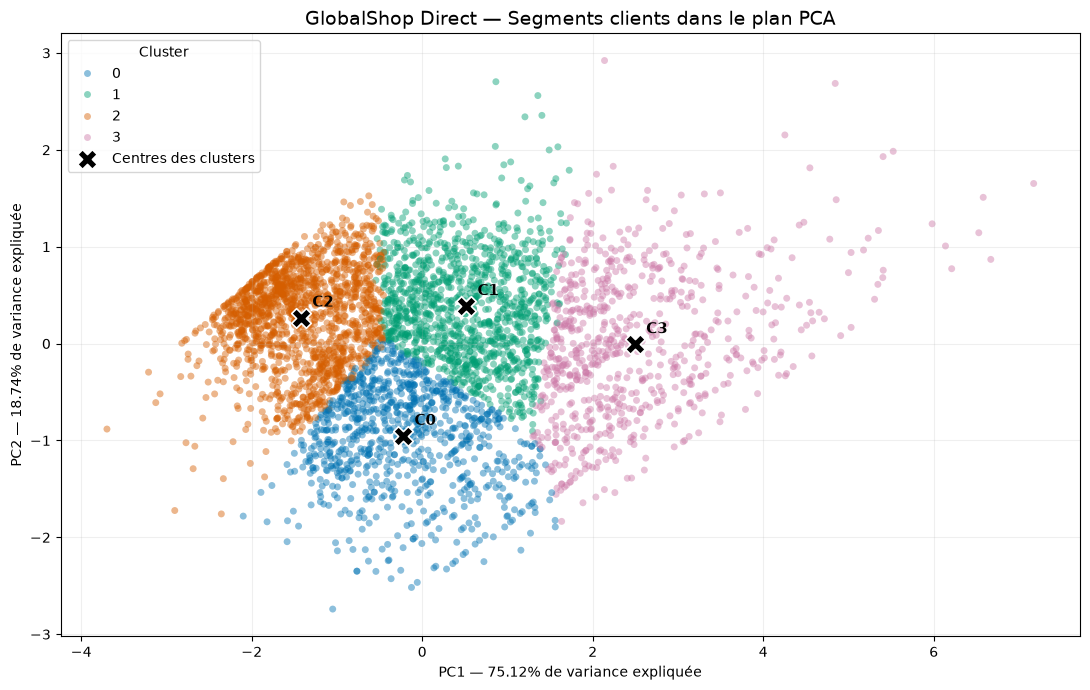

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Projeter les centres K-Means avec la même PCA que les clients.
centres_pca = pca.transform(modele_kmeans.cluster_centers_)

fig, ax = plt.subplots(figsize=(11, 7))

# Un point = un client ; une couleur = un cluster.
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    hue_order=["0", "1", "2", "3"],
    palette=couleurs_clusters,
    alpha=0.45,
    s=25,
    linewidth=0,
    ax=ax
)

# Afficher les centres projetés.
ax.scatter(
    centres_pca[:, 0],
    centres_pca[:, 1],
    marker="X",
    s=200,
    color="black",
    edgecolors="white",
    linewidths=1.2,
    label="Centres des clusters",
    zorder=5
)

# Identifier chaque centre par son numéro de cluster.
for numero_cluster, centre in enumerate(centres_pca):
    ax.annotate(
        f"C{numero_cluster}",
        xy=(centre[0], centre[1]),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=11,
        fontweight="bold"
    )

ax.set_title(
    "GlobalShop Direct — Segments clients dans le plan PCA",
    fontsize=14
)
ax.set_xlabel(
    f"PC1 — {pca.explained_variance_ratio_[0]:.2%} de variance expliquée"
)
ax.set_ylabel(
    f"PC2 — {pca.explained_variance_ratio_[1]:.2%} de variance expliquée"
)
ax.legend(title="Cluster")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

###  ### Interprétation de la projection PCA

Le graphique montre **quatre zones reconnaissables**, avec des chevauchements naturels aux frontières. C’est parfaitement cohérent avec le score de silhouette de **0,333** pour $K=4$ : les segments présentent de vraies différences métier, mais leur séparation géométrique reste partielle.

> 📍 *Note : Les croix noires sur le graphique représentent les centres (centroïdes) des clusters projetés sur le plan PCA.*

| Cluster | Position observée sur le plan PCA | Profil identifié (médianes RFM) |
| :---: | :--- | :--- |
| **0 (Bleu)** | Partie inférieure du graphique | Achats récents, fréquence et montant faibles |
| **1 (Vert)** | Zone centrale, plutôt supérieure | Achats réguliers, montant intermédiaire |
| **2 (Orange)** | Partie gauche du graphique | Achats anciens, fréquence et montant faibles |
| **3 (Rose)** | Partie droite, avec une forte dispersion | Achats très récents, fréquence et montant très élevés |

---
Des chevauchements apparaissent aux frontières des groupes. La segmentation
décrit donc des profils différenciés au sein d’une population dont les
comportements évoluent progressivement.

Cette représentation complète l’analyse des profils RFM et du score de
silhouette. Elle ne suffit pas, à elle seule, à démontrer que quatre clusters
constituent le meilleur choix.

L’interprétation métier des axes nécessite d’examiner les coefficients
associés à la récence, à la fréquence et au montant.


💡 **Raccordement avec l'analyse fonctionnelle :**

Ces descriptions métier s'appuient directement sur les profils RFM calculés précédemment. Pour comprendre plus précisément la logique spatiale (pourquoi un client se situe à droite, à gauche ou en bas), nous devons maintenant examiner la composition analytique des deux axes $\text{PC1}$ et $\text{PC2}$ (cercles des corrélations / *loadings*).

### 7.3 : Contribution des variables à la construction des axes

**Question d’analyse :** quelles dimensions du comportement d’achat
expliquent la position des clients dans le plan PCA ?

Nous examinons les coefficients des variables RFM dans chaque composante
principale. Un coefficient positif signifie qu’une augmentation de la
variable contribue à augmenter la coordonnée sur cet axe, toutes les
autres variables étant maintenues constantes.

Un coefficient négatif indique le sens inverse. Plus sa valeur absolue
est élevée, plus la variable intervient dans la construction de l’axe.

Ces coefficients concernent les variables après transformation
logarithmique et standardisation.

In [36]:
# Les lignes correspondent aux variables utilisées par la PCA.
# Les colonnes correspondent aux trois composantes principales.
coefficients_pca = pd.DataFrame(
    pca.components_.T,
    index=X_scaled.columns,
    columns=["PC1", "PC2", "PC3"]
)

display(coefficients_pca.round(3))

,PC1,PC2,PC3
recence,-0.512,0.850,0.126
frequence,0.618,0.262,0.741
montant_total,0.597,0.458,-0.659


### Interprétation des composantes principales

Les coefficients concernent les variables RFM après transformation
logarithmique et standardisation.

**PC1 - Un axe d’activité d’achat**

PC1 explique 75,12 % de la variance. Elle associe positivement la
fréquence (0,618) et le montant (0,597), et négativement la récence
(-0,512).

Une coordonnée élevée sur cet axe correspond généralement à des achats plus fréquents, plus importants et plus récents. Cette lecture explique
la position du cluster 3, composé des clients les plus actifs, à droite du graphique.

À l’inverse, le cluster 2, caractérisé par des achats anciens et peu fréquents, se situe principalement à gauche.

**PC2 - Un axe fortement associé à la récence**

PC2 explique 18,74 % de la variance. La récence présente le coefficient le plus élevé (0,850), suivie du montant (0,458) et de la fréquence
(0,262).

À fréquence et montant identiques, une récence plus élevée augmente la coordonnée sur PC2. Cet axe combine néanmoins les trois variables
et ne doit pas être interprété comme une simple mesure de récence.

La position du cluster 0 dans la partie inférieure est cohérente avec ses achats récents, sa faible fréquence et ses montants modestes.

**PC3 - Une opposition complémentaire entre fréquence et montant**

PC3 explique les 6,14 % restants. Elle oppose principalement la fréquence (0,741) au montant (-0,659). Cette dimension n’apparaît pas
dans la projection en deux dimensions.

### Bilan de l’analyse PCA

Le plan PC1–PC2 représente 93,86 % de la variance des données prétraitées. Il fournit une représentation synthétique des différences entre les
segments et complète leur interprétation à partir des profils RFM.

Les chevauchements visibles rappellent que les groupes ne sont pas totalement séparés. La PCA complète l’évaluation du clustering sans
constituer, à elle seule, une validation du choix de quatre clusters.

## Étape 8 : Profilage métier des segments et recommandations marketing

### Question métier

Quels profils d’achat caractérisent les quatre segments et quelles
actions marketing pouvons-nous proposer pour chacun ?

### Méthodologie

Pour chaque cluster, nous analysons :
- le nombre de clients et leur part dans la population ;
- la moyenne et la médiane de chaque variable RFM ;
- le montant cumulé des achats retenus et sa part dans le montant global.

Les profils sont interprétés à partir des variables RFM originales. Les médianes sont privilégiées pour décrire les comportements typiques,
car les moyennes peuvent être influencées par les clients aux dépenses très élevées.

Les noms des segments constituent une interprétation métier des résultats. Les actions proposées sont des hypothèses à tester lors de campagnes.

### Périmètre

Les profils décrivent les achats observés sur la période étudiée, avec une récence calculée au 10 décembre 2011.

Le montant correspond aux achats positifs retenus après nettoyage. Il ne représente ni un chiffre d’affaires net des retours ni une marge.

In [37]:
# Calculer les caractéristiques des clusters sur les valeurs RFM originales.
profils_segments = (
    rfm_segments
    .groupby("cluster")
    .agg(
        effectif=("id_client", "size"),
        recence_moyenne=("recence", "mean"),
        recence_mediane=("recence", "median"),
        frequence_moyenne=("frequence", "mean"),
        frequence_mediane=("frequence", "median"),
        montant_moyen=("montant_total", "mean"),
        montant_median=("montant_total", "median"),
        montant_cumule=("montant_total", "sum")
    )
)

# Mesurer le poids de chaque segment.
profils_segments["part_clients_pct"] = (
    profils_segments["effectif"] / len(rfm_segments) * 100
)

profils_segments["part_montant_pct"] = (
    profils_segments["montant_cumule"]
    / rfm_segments["montant_total"].sum()
    * 100
)

# Arrondir uniquement l'affichage.
display(profils_segments.round(2))

,effectif,recence_moyenne,recence_mediane,frequence_moyenne,frequence_mediane,montant_moyen,montant_median,montant_cumule,part_clients_pct,part_montant_pct
cluster,,,,,,,,,,
0,897,22.79,20.0,1.92,2.0,486.06,414.20,435999.12,20.68,4.91
1,1174,65.29,52.0,4.19,4.0,1822.98,1355.04,2140183.49,27.06,24.08
2,1549,192.27,187.0,1.35,1.0,360.55,303.16,558489.10,35.71,6.28
3,718,12.21,9.0,13.64,10.0,8011.89,3687.77,5752537.18,16.55,64.73


###  8.3 : Nommer les segments

D’après les résultats obtenus et l'analyse métier approfondie des profils RFM, nous retenons la nomenclature définitive suivante :

| Cluster | Nom du segment | Clients | Récence médiane | Commandes médianes | Montant médian* |
| :---: | :--- | :---: | :---: | :---: | :---: |
| **0** | **Occasionnels récents** | 897 | 20 jours | 2 | 414,20 € |
| **1** | **Acheteurs réguliers** | 1 174 | 52 jours | 4 | 1 355,04 € |
| **2** | **Occasionnels en sommeil** | 1 549 | 187 jours | 1 | 303,16 € |
| **3** | **Champions** | 718 | 9 jours | 10 | 3 687,77 € |

---

* **Distinction Récence vs Ancienneté :** Un achat récent ne garantit pas qu'il s'agisse d'un nouveau client (la récence mesure uniquement le délai depuis la dernière transaction).
* **Nuance pour le Cluster 2 :** Nous privilégions le nom **« Occasionnels en sommeil »** plutôt que « Fidèles à risque ». Avec une médiane d'une seule commande, l'historique ne démontre pas une fidélité passée, mais simplement un achat ancien resté sans suite.

In [38]:
# Ces noms correspondent aux numéros du modèle K-Means retenu.
noms_segments = {
    0: "Occasionnels récents",
    1: "Acheteurs réguliers",
    2: "Occasionnels en sommeil",
    3: "Champions"
}

# Ajouter le nom métier à chaque profil client.
rfm_segments["segment"] = rfm_segments["cluster"].map(noms_segments)

# Ajouter le nom au tableau de synthèse.
profils_segments.insert(
    0,
    "segment",
    profils_segments.index.map(noms_segments)
)

# Vérifier que tous les clients ont un segment nommé.
assert rfm_segments["segment"].notna().all(), \
    "Certains clusters ne disposent pas d'un nom métier."

display(profils_segments.round(2))
display(rfm_segments.head())

,segment,effectif,recence_moyenne,recence_mediane,frequence_moyenne,frequence_mediane,montant_moyen,montant_median,montant_cumule,part_clients_pct,part_montant_pct
cluster,,,,,,,,,,,
0,Occasionnels récents,897,22.79,20.0,1.92,2.0,486.06,414.20,435999.12,20.68,4.91
1,Acheteurs réguliers,1174,65.29,52.0,4.19,4.0,1822.98,1355.04,2140183.49,27.06,24.08
2,Occasionnels en sommeil,1549,192.27,187.0,1.35,1.0,360.55,303.16,558489.10,35.71,6.28
3,Champions,718,12.21,9.0,13.64,10.0,8011.89,3687.77,5752537.18,16.55,64.73


,id_client,recence,frequence,montant_total,cluster,segment
0,12346.0,326,1,77183.60,1,Acheteurs réguliers
1,12347.0,3,7,4310.00,3,Champions
2,12348.0,76,4,1797.24,1,Acheteurs réguliers
3,12349.0,19,1,1757.55,0,Occasionnels récents
4,12350.0,311,1,334.40,2,Occasionnels en sommeil


### Recommandations marketing

| Segment | Comportement observé | Objectif marketing | Actions à tester | Indicateur de suivi |
|---|---|---|---|---|
| Occasionnels récents | Achats récents, peu de commandes et montant modeste | Encourager un achat supplémentaire | Recommandations de produits complémentaires et relance après achat | Taux de nouvel achat à 60 jours |
| Acheteurs réguliers | Plusieurs commandes et montant intermédiaire | Entretenir la relation et développer les achats | Communication personnalisée et recommandations adaptées à l’historique | Nombre de commandes par client sur 90 jours |
| Occasionnels en sommeil | Dernier achat ancien et peu de commandes | Réactiver les clients intéressés | Campagne de retour et test d’une offre ciblée | Taux de réactivation à 60 jours |
| Champions | Achats très récents, fréquents et montants élevés | Maintenir une relation durable | Avantages de fidélité, accès anticipé et service personnalisé | Taux de réachat à 90 jours |

### Priorités pour GlobalShop Direct

Les Champions représentent 16,55 % des clients et concentrent 64,73 %
du montant des achats retenus. Leur poids justifie une attention
particulière à la qualité de la relation client.

Les Occasionnels en sommeil représentent 35,71 % des clients, pour
6,28 % du montant. Une campagne de réactivation pourrait être testée
sur une partie de ce segment avant d’étendre les dépenses marketing.

Les Occasionnels récents constituent un public pour des actions
encourageant un achat supplémentaire. Les Acheteurs réguliers peuvent
faire l’objet d’actions visant à entretenir leur engagement.

### Évaluation des recommandations

Les actions proposées ne garantissent pas une augmentation des achats.
Pour mesurer leur efficacité, chaque campagne devrait comparer un groupe
sollicité à un groupe témoin comparable, sur une durée définie.

Cette comparaison permettra d’évaluer les achats supplémentaires générés
par la campagne, au-delà des achats qui auraient eu lieu spontanément.

### 8.5 : Comparaison des distributions RFM par segment

**Question d’analyse :** les différences entre les segments concernent-elles
la majorité des clients ou sont-elles influencées par quelques profils extrêmes ?

Les boxplots présentent, pour chaque segment :
- la médiane, représentée par le trait à l’intérieur de la boîte ;
- les 50 % centraux des observations, compris entre les premier et troisième quartiles ;
- les moustaches, définies selon la règle de 1,5 fois l’intervalle interquartile ;
- les observations situées au-delà des moustaches.

Les points au-delà des moustaches correspondent à des valeurs atypiques
selon cette règle. Ils ne sont pas automatiquement considérés comme des erreurs.

Les graphiques utilisent les valeurs RFM originales. Une échelle logarithmique
est utilisée pour la fréquence et le montant afin de faciliter la lecture
des valeurs très dispersées. Elle ne modifie pas les données du tableau.

Les noms des segments décrivent leurs comportements dominants.
Ils ne constituent pas des règles individuelles d’appartenance.

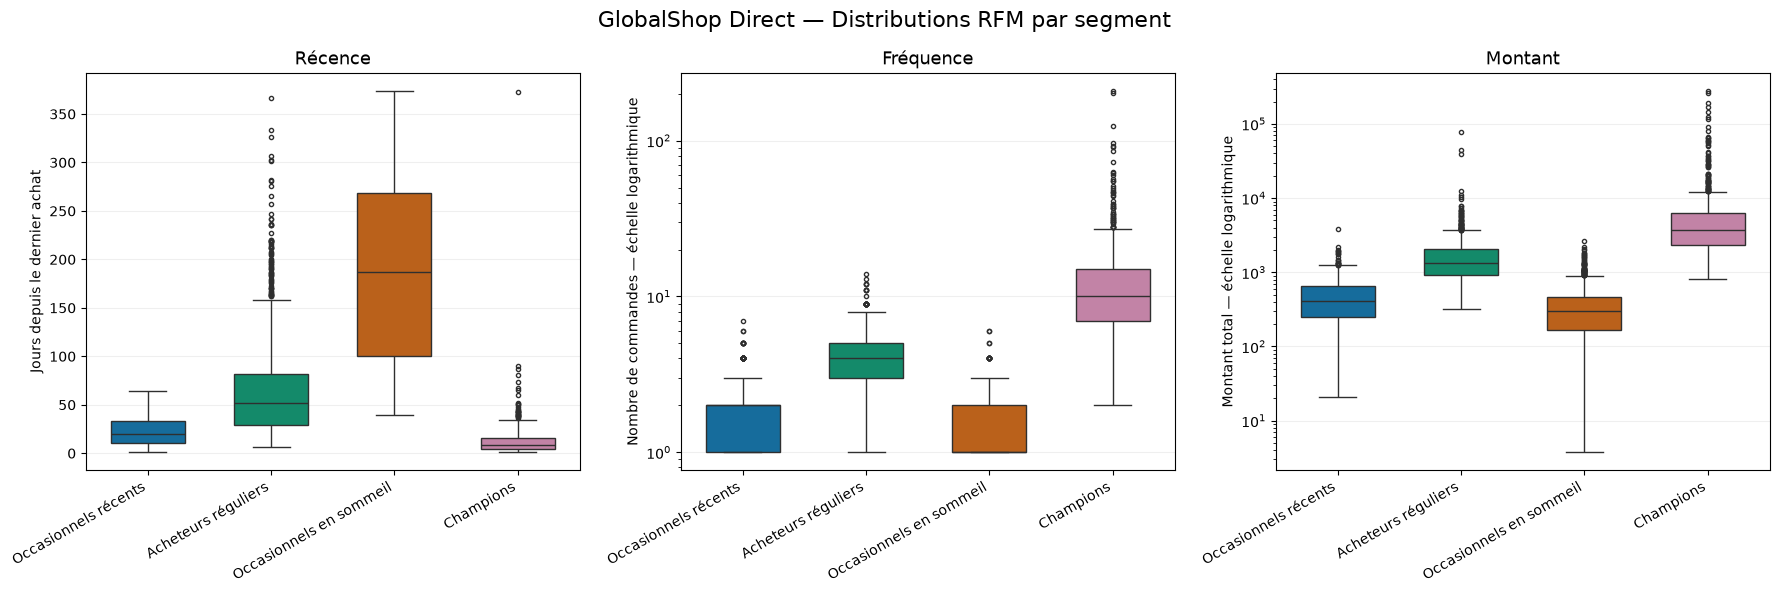

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Conserver l'ordre des clusters et les couleurs des graphiques précédents.
ordre_segments = [noms_segments[k] for k in range(4)]

palette_segments = {
    noms_segments[k]: couleurs_clusters[str(k)]
    for k in range(4)
}

graphiques = [
    ("recence", "Récence", "Jours depuis le dernier achat"),
    ("frequence", "Fréquence", "Nombre de commandes — échelle logarithmique"),
    ("montant_total", "Montant", "Montant total — échelle logarithmique")
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (variable, titre, label_y) in zip(axes, graphiques):
    sns.boxplot(
        data=rfm_segments,
        x="segment",
        y=variable,
        order=ordre_segments,
        hue="segment",
        hue_order=ordre_segments,
        palette=palette_segments,
        dodge=False,
        width=0.6,
        showfliers=True,
        fliersize=3,
        ax=ax
    )

    # La légende répète les noms déjà présents sur l'axe horizontal.
    legende = ax.get_legend()
    if legende is not None:
        legende.remove()

    # Toutes les fréquences et tous les montants sont strictement positifs.
    if variable in ["frequence", "montant_total"]:
        ax.set_yscale("log")

    ax.set_title(titre, fontsize=13)
    ax.set_xlabel("")
    ax.set_ylabel(label_y)
    ax.tick_params(axis="x", labelrotation=30)

    for etiquette in ax.get_xticklabels():
        etiquette.set_horizontalalignment("right")

    ax.grid(axis="y", alpha=0.2)

fig.suptitle(
    "GlobalShop Direct — Distributions RFM par segment",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Interprétation des distributions RFM par segment

#### Récence

Les Champions présentent la récence médiane la plus faible, avec 9 jours,
suivis des Occasionnels récents, avec 20 jours.

Les Acheteurs réguliers ont une récence médiane de 52 jours, mais certains
clients de ce groupe ont des achats nettement plus anciens.

Les Occasionnels en sommeil se distinguent par une récence médiane de
187 jours et une dispersion importante. Leur dernier achat est généralement
plus ancien que celui des clients des autres segments.

#### Fréquence

Les Champions présentent une fréquence médiane de 10 commandes, contre
4 pour les Acheteurs réguliers.

Les Occasionnels récents et les Occasionnels en sommeil ont des fréquences
faibles, avec respectivement 2 et 1 commande en médiane. La fréquence seule
permet donc difficilement de distinguer ces deux segments.

#### Montant

Le montant médian est le plus élevé chez les Champions : 3 687,77,
contre 1 355,04 pour les Acheteurs réguliers.

Les Occasionnels récents et les Occasionnels en sommeil présentent des
montants médians plus modestes, respectivement 414,20 et 303,16.

Des montants très élevés apparaissent notamment chez les Champions
et les Acheteurs réguliers. Ils expliquent en partie pourquoi les
moyennes dépassent les médianes dans ces groupes.

#### Synthèse et limites

Les distributions confortent la lecture métier des segments :
- les Champions combinent achats récents, fréquence élevée et montants importants ;
- les Acheteurs réguliers présentent une activité intermédiaire ;
- les deux groupes d’Occasionnels se différencient principalement par la récence.

Les chevauchements et les observations atypiques montrent que chaque segment
contient des profils variés. Les noms décrivent les comportements dominants
des groupes et ne constituent pas des règles applicables à chaque client.

Ces graphiques décrivent la segmentation obtenue sur les mêmes variables
que celles utilisées par K-Means. Ils complètent son interprétation,
sans constituer une validation indépendante.

### 8.6 : Poids des segments dans la clientèle et dans les achats

**Question métier :** quels segments concentrent le montant des achats
et quelle place occupent-ils dans la base client ?

Pour chaque segment, nous comparons :
- sa part dans les 4 338 clients retenus ;
- sa part dans le montant total des achats retenus.

Une part du montant supérieure à la part des clients indique que le montant
moyen par client du segment dépasse la moyenne globale.

Cette comparaison aide à orienter les priorités marketing. Elle décrit
les achats historiques et ne mesure ni la rentabilité des clients
ni leur valeur future.

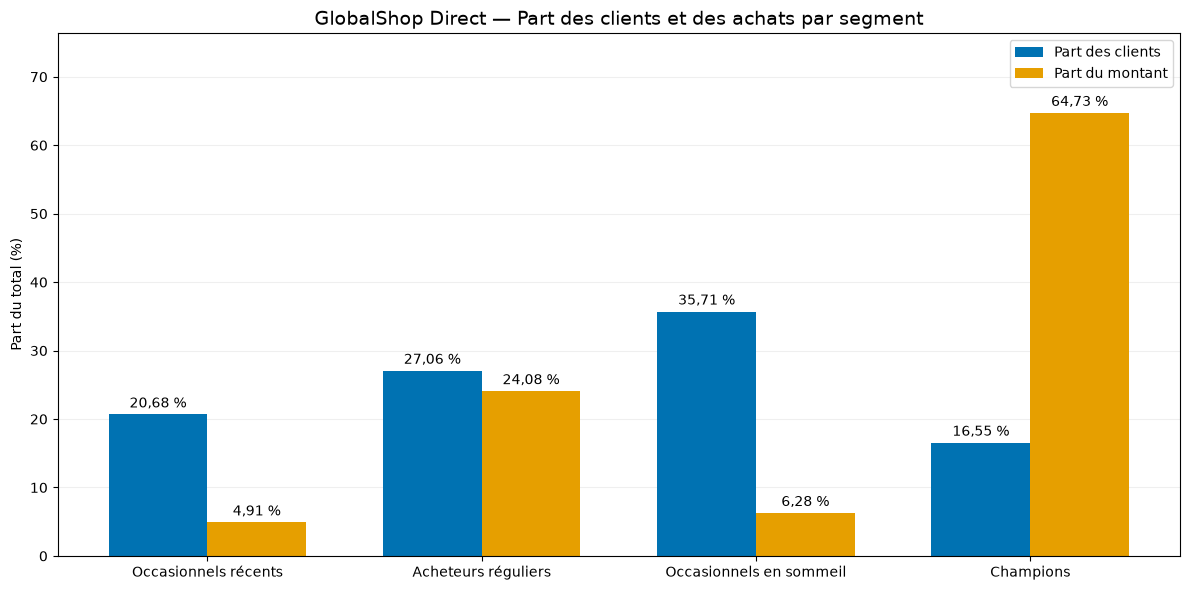

In [40]:
# Préparer les données sans modifier le tableau de profilage.
poids_segments = profils_segments[
    ["segment", "part_clients_pct", "part_montant_pct"]
].copy()

positions = np.arange(len(poids_segments))
largeur = 0.36

fig, ax = plt.subplots(figsize=(12, 6))

barres_clients = ax.bar(
    positions - largeur / 2,
    poids_segments["part_clients_pct"],
    width=largeur,
    color="#0072B2",
    label="Part des clients"
)

barres_montant = ax.bar(
    positions + largeur / 2,
    poids_segments["part_montant_pct"],
    width=largeur,
    color="#E69F00",
    label="Part du montant"
)

# Ajouter les pourcentages au-dessus des barres.
for groupe_barres in [barres_clients, barres_montant]:
    for barre in groupe_barres:
        valeur = barre.get_height()
        etiquette = f"{valeur:.2f} %".replace(".", ",")

        ax.annotate(
            etiquette,
            xy=(barre.get_x() + barre.get_width() / 2, valeur),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=10
        )

ax.set_xticks(positions)
ax.set_xticklabels(poids_segments["segment"])
ax.set_ylabel("Part du total (%)")
ax.set_ylim(
    0,
    poids_segments[["part_clients_pct", "part_montant_pct"]]
    .to_numpy().max() * 1.18
)
ax.set_title(
    "GlobalShop Direct — Part des clients et des achats par segment",
    fontsize=14
)
ax.legend()
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Interprétation et priorités marketing

**Champions - Préserver la relation**

Les Champions représentent 16,55 % des clients et concentrent 64,73 %
du montant des achats retenus. Cette concentration justifie une attention
particulière à leur satisfaction et à leur fidélisation.

**Acheteurs réguliers - Entretenir l’engagement**

Les Acheteurs réguliers représentent 27,06 % des clients et 24,08 %
du montant. Ils constituent une part importante de la clientèle.
Des recommandations personnalisées et des actions de fidélisation
peuvent être testées pour entretenir leur activité.

**Occasionnels récents - Encourager un achat supplémentaire**

Les Occasionnels récents représentent 20,68 % des clients et 4,91 %
du montant. Leur dernier achat étant récent, des recommandations
complémentaires peuvent être testées pour encourager une nouvelle commande.

**Occasionnels en sommeil - Tester la réactivation**

Les Occasionnels en sommeil constituent le segment le plus nombreux :
35,71 % des clients, pour 6,28 % du montant. Une campagne de réactivation
sur un échantillon permettrait d’évaluer leur réponse avant d’engager
un budget plus important.

### Limite de la comparaison

Ces proportions décrivent la période observée. Un faible montant historique
ne signifie pas nécessairement un faible potentiel futur.

Les budgets marketing devront également tenir compte du coût des actions,
de la marge et des résultats obtenus lors de tests avec un groupe témoin.

## Étape 9 : Préparation des données pour le dashboard Data Studio

### Objectif

Construire une table de restitution regroupant les profils RFM,
les segments, les coordonnées PCA et les recommandations marketing.

### Granularité

Chaque ligne représente un client identifié ayant au moins un achat
retenu après nettoyage. Le tableau doit contenir 4 338 clients distincts.

### Contenu

| Variable | Définition |
|---|---|
| id_client | Identifiant du client, conservé comme texte |
| recence | Nombre de jours depuis le dernier achat |
| frequence | Nombre de commandes distinctes sur la période |
| montant_total | Somme des montants des achats retenus |
| cluster | Numéro du groupe attribué par K-Means |
| segment | Nom métier du groupe |
| PC1, PC2 | Coordonnées du client dans le plan PCA |
| objectif_marketing | Objectif proposé pour le segment |
| action_recommandee | Action marketing à tester |
| indicateur_suivi | Indicateur proposé pour évaluer la campagne |
| date_reference | Date utilisée pour calculer la récence |

Les variables RFM sont conservées dans leurs unités originales.
Les coordonnées PCA proviennent des variables transformées et standardisées.

Les recommandations sont définies au niveau du segment : elles ne sont
pas personnalisées à partir des produits achetés par chaque client.

In [41]:
# Une ligne par cluster : ces numéros correspondent au modèle retenu.
recommandations = pd.DataFrame([
    {
        "cluster": 0,
        "objectif_marketing": "Encourager un achat supplémentaire",
        "action_recommandee": (
            "Tester une relance après achat avec des produits complémentaires"
        ),
        "indicateur_suivi": "Taux de nouvel achat à 60 jours"
    },
    {
        "cluster": 1,
        "objectif_marketing": "Entretenir la relation et développer les achats",
        "action_recommandee": (
            "Tester des recommandations adaptées à l'historique d'achat"
        ),
        "indicateur_suivi": "Nombre de commandes par client sur 90 jours"
    },
    {
        "cluster": 2,
        "objectif_marketing": "Réactiver les clients",
        "action_recommandee": (
            "Tester une campagne de retour avec une offre ciblée"
        ),
        "indicateur_suivi": "Taux de réactivation à 60 jours"
    },
    {
        "cluster": 3,
        "objectif_marketing": "Maintenir une relation durable",
        "action_recommandee": (
            "Tester des avantages de fidélité et un accès anticipé"
        ),
        "indicateur_suivi": "Taux de réachat à 90 jours"
    }
])

display(recommandations)

,cluster,objectif_marketing,action_recommandee,indicateur_suivi
0,0,Encourager un achat supplémentaire,Tester une relance après achat avec des produi...,Taux de nouvel achat à 60 jours
1,1,Entretenir la relation et développer les achats,Tester des recommandations adaptées à l'histor...,Nombre de commandes par client sur 90 jours
2,2,Réactiver les clients,Tester une campagne de retour avec une offre c...,Taux de réactivation à 60 jours
3,3,Maintenir une relation durable,Tester des avantages de fidélité et un accès a...,Taux de réachat à 90 jours


In [42]:
# Vérifier l'alignement des tableaux issus des étapes précédentes.
assert rfm_segments.index.is_unique
assert rfm_segments.index.equals(X_scaled.index)
assert rfm_segments.index.equals(df_pca.index)

# Vérifier également la cohérence des affectations.
assert np.array_equal(
    rfm_segments["cluster"].astype(str).to_numpy(),
    df_pca["cluster"].astype(str).to_numpy()
)

# Copier les profils clients et ajouter les coordonnées PCA par index.
clients_dashboard = rfm_segments.copy()
clients_dashboard[["PC1", "PC2"]] = df_pca[["PC1", "PC2"]]

# Ajouter les recommandations sans multiplier les lignes clients.
clients_dashboard = clients_dashboard.merge(
    recommandations,
    on="cluster",
    how="left",
    validate="many_to_one"
)

# Les identifiants du fichier sont numériques, mais désignent des clients.
# Vérifier qu'ils sont entiers avant d'enlever le suffixe ".0".
assert clients_dashboard["id_client"].notna().all()
assert clients_dashboard["id_client"].mod(1).eq(0).all()

clients_dashboard["id_client"] = (
    clients_dashboard["id_client"]
    .astype("int64")
    .astype("string")
)

# Documenter la date de référence du profil RFM.
clients_dashboard["date_reference"] = pd.Timestamp(date_reference).normalize()

# Organiser les colonnes pour la restitution.
colonnes_dashboard = [
    "id_client",
    "recence",
    "frequence",
    "montant_total",
    "cluster",
    "segment",
    "PC1",
    "PC2",
    "objectif_marketing",
    "action_recommandee",
    "indicateur_suivi",
    "date_reference"
]

clients_dashboard = clients_dashboard[colonnes_dashboard]

display(clients_dashboard.head())
print("Dimensions :", clients_dashboard.shape)

,id_client,recence,frequence,montant_total,cluster,segment,PC1,PC2,objectif_marketing,action_recommandee,indicateur_suivi,date_reference
0,12346,326,1,77183.60,1,Acheteurs réguliers,0.864418,2.702790,Entretenir la relation et développer les achats,Tester des recommandations adaptées à l'histor...,Nombre de commandes par client sur 90 jours,2011-12-10
1,12347,3,7,4310.00,3,Champions,2.476394,-0.676603,Maintenir une relation durable,Tester des avantages de fidélité et un accès a...,Taux de réachat à 90 jours,2011-12-10
2,12348,76,4,1797.24,1,Acheteurs réguliers,0.477497,0.747222,Entretenir la relation et développer les achats,Tester des recommandations adaptées à l'histor...,Nombre de commandes par client sur 90 jours,2011-12-10
3,12349,19,1,1757.55,0,Occasionnels récents,0.166544,-0.489124,Encourager un achat supplémentaire,Tester une relance après achat avec des produi...,Taux de nouvel achat à 60 jours,2011-12-10
4,12350,311,1,334.40,2,Occasionnels en sommeil,-1.695893,0.693916,Réactiver les clients,Tester une campagne de retour avec une offre c...,Taux de réactivation à 60 jours,2011-12-10


Dimensions : (4338, 12)


In [43]:
controles_dashboard = pd.Series({
    "Nombre de lignes conservé":
        len(clients_dashboard) == len(rfm_segments),

    "Une ligne par client":
        clients_dashboard["id_client"].is_unique,

    "Aucune valeur manquante":
        clients_dashboard.notna().all().all(),

    "Coordonnées PCA finies":
        np.isfinite(clients_dashboard[["PC1", "PC2"]].to_numpy()).all(),

    "Noms des segments cohérents":
        clients_dashboard["segment"].eq(
            clients_dashboard["cluster"].map(noms_segments)
        ).all(),

    "Montant global conservé":
        np.isclose(
            clients_dashboard["montant_total"].sum(),
            rfm_segments["montant_total"].sum()
        ),

    "Effectifs par cluster conservés":
        clients_dashboard.groupby("cluster").size().equals(
            rfm_segments.groupby("cluster").size()
        )
}, name="controle_valide")

display(controles_dashboard.to_frame())

assert controles_dashboard.all(), \
    "Un contrôle a échoué : vérifier la table avant l'export."

,controle_valide
Nombre de lignes conservé,True
Une ligne par client,True
Aucune valeur manquante,True
Coordonnées PCA finies,True
Noms des segments cohérents,True
Montant global conservé,True
Effectifs par cluster conservés,True


### 9.5 : Export de la table client

La table est exportée au format CSV pour préparer sa connexion au dashboard.

Le fichier contient une ligne par client, avec les variables RFM originales,
le segment attribué, les coordonnées PCA et les recommandations marketing.

L’export conserve la précision des valeurs numériques. Les arrondis seront
appliqués lors de leur affichage dans le dashboard.

L’identifiant client devra être configuré comme un champ texte dans
l’outil de restitution.

In [44]:
from pathlib import Path

# Exporter uniquement après validation des contrôles.
assert controles_dashboard.all(), \
    "Les contrôles doivent être validés avant l'export."

# Chemin relatif au dossier depuis lequel le notebook est exécuté.
dossier_exports = Path("exports")
dossier_exports.mkdir(parents=True, exist_ok=True)

fichier_clients = dossier_exports / "globalshop_clients_segments.csv"

clients_dashboard.to_csv(
    fichier_clients,
    index=False,               # Ne pas exporter l'index Pandas.
    encoding="utf-8-sig",       # Conserver les accents.
    date_format="%Y-%m-%d"
)

print("Fichier exporté :", fichier_clients.resolve())
print("Nombre de clients :", len(clients_dashboard))

Fichier exporté : /Users/loic.boni/Desktop/formation DATA ANALYST/Machine Learning /Introduction à l'Apprentissage Non Supervisé/notebooks/exports/globalshop_clients_segments.csv
Nombre de clients : 4338


In [45]:
verification_export = pd.read_csv(
    fichier_clients,
    dtype={"id_client": "string"},
    parse_dates=["date_reference"]
)

controles_export = pd.Series({
    "Dimensions conservées":
        verification_export.shape == clients_dashboard.shape,

    "Colonnes conservées":
        verification_export.columns.equals(clients_dashboard.columns),

    "Identifiants conservés":
        verification_export["id_client"].equals(
            clients_dashboard["id_client"].reset_index(drop=True)
        ),

    "Aucune valeur manquante":
        verification_export.notna().all().all(),

    "Montant global conservé":
        np.isclose(
            verification_export["montant_total"].sum(),
            clients_dashboard["montant_total"].sum()
        )
}, name="controle_valide")

display(controles_export.to_frame())

assert controles_export.all(), \
    "Un contrôle du fichier exporté a échoué."

,controle_valide
Dimensions conservées,True
Colonnes conservées,True
Identifiants conservés,True
Aucune valeur manquante,True
Montant global conservé,True


In [46]:
from sklearn.model_selection import train_test_split
from pathlib import Path

# Tirage aléatoire proportionnel aux effectifs des segments
clients_pca, _ = train_test_split(
    clients_dashboard,
    train_size=1000,
    stratify=clients_dashboard["segment"],
    random_state=42
)

# Export destiné uniquement au graphique PCA
dossier_export = Path("exports")
dossier_export.mkdir(parents=True, exist_ok=True)

fichier_pca = dossier_export / "globalshop_pca_echantillon.csv"

clients_pca.to_csv(
    fichier_pca,
    index=False,
    encoding="utf-8-sig"
)

print("Clients sélectionnés :", len(clients_pca))
print("Fichier exporté :", fichier_pca.resolve())

display(clients_pca["segment"].value_counts())

Clients sélectionnés : 1000
Fichier exporté : /Users/loic.boni/Desktop/formation DATA ANALYST/Machine Learning /Introduction à l'Apprentissage Non Supervisé/notebooks/exports/globalshop_pca_echantillon.csv


segment
Occasionnels en sommeil    357
Acheteurs réguliers        271
Occasionnels récents       207
Champions                  165
Name: count, dtype: int64

### Bilan de la préparation des données

Le fichier `globalshop_clients_segments.csv` contient 4 338 profils clients
et 12 variables : les métriques RFM, le cluster, le nom du segment,
les coordonnées PCA, les recommandations marketing et la date de référence.

La relecture du fichier permet de contrôler la conservation des données
avant leur utilisation dans le dashboard.

## Étape 10 : Conception du dashboard marketing

### Public cible

Le dashboard s’adresse à la direction marketing et aux équipes chargées
des campagnes de GlobalShop Direct.

### Questions métier

1. Quelle est la taille de la clientèle analysée et quel montant représente-t-elle ?
2. Quels segments concentrent les achats ?
3. Quelles différences de comportement caractérisent les segments ?
4. Quels clients cibler et quelles actions tester ?

### Source et périmètre

La source principale est `globalshop_clients_segments.csv`.
Elle contient une ligne par client, soit 4 338 profils.

Les profils résument les achats retenus entre le 1er décembre 2010
et le 9 décembre 2011. La récence est calculée au 10 décembre 2011.

Le montant correspond aux achats positifs retenus après nettoyage.
Les annulations et retours sont exclus.

### Organisation du rapport

Le dashboard comprend trois pages :
1. Vue d’ensemble : taille de la clientèle et poids des segments.
2. Profils des segments : comparaison des comportements RFM et projection PCA.
3. Ciblage marketing : consultation des clients et recommandations associées.


### Définir les KPI (Indicateurs Clés de Performance)

Ces métriques globales servent de référence pour valider l'exactitude du tableau de bord en l'absence de filtre actif. Lors de l'application de filtres, l'ensemble des indicateurs doit se recalculer pour refléter uniquement le périmètre client sélectionné.

| KPI | Calcul sur la table client | Valeur globale attendue |
| :--- | :--- | :---: |
| **Clients analysés** | Nombre distinct de `id_client` | **4 338** |
| **Montant des achats retenus** | Somme de `montant_total` | **8 887 208,89 €** |
| **Montant moyen par client** | Moyenne de `montant_total` | **2 048,69 €** |
| **Fréquence moyenne** | Moyenne de `frequence` | **4,27 commandes** |
| **Récence médiane** | Médiane de `recence` | **51 jours** |

> ⚠️ **Nuance importante :** Le **montant moyen par client** ne correspond pas au panier moyen par commande. Il mesure le chiffre d'affaires cumulé généré par un client unique sur l'ensemble de la période d'analyse.

---

### Définir les filtres du Dashboard

Afin de permettre une exploration ciblée, le tableau de bord intégrera les filtres interactifs suivants :

| Filtre | Usage opérationnel |
| :--- | :--- |
| **Segment** | Consulter un ou plusieurs groupes de la segmentation K-Means ($K=4$). |
| **Identifiant client** | Retrouver le profil individuel d'un client précis via `id_client`. |
| **Récence** | Filtrer l'effectif selon le nombre de jours écoulés depuis le dernier achat. |
| **Fréquence** | Cibler une tranche spécifique du nombre de commandes passées. |
| **Montant total** | Sélectionner la population selon le volume de dépenses cumulées. |

---

💡 **Limite fonctionnelle et périmètre des données :**
La table préparée actuelle repose sur une valeur unique `date_reference`, partagée par l'ensemble des clients. En l'état, elle ne permet pas d'effectuer une analyse temporelle des ventes (suivi mensuel ou saisonnalité). Pour intégrer ces visions chronologiques, une jointure avec la base transactionnelle brute comportant le détail horodaté de chaque facture serait requise.
### Règles de lecture

- L’identifiant client et le cluster sont des dimensions, pas des mesures à sommer.
- Le nombre de clients est calculé par comptage distinct des identifiants.
- Le montant total est additionné pour mesurer les achats retenus.
- La récence et la fréquence sont présentées avec une moyenne ou une médiane,
  selon la question étudiée.
- Le scatterplot PCA doit représenter un point par client.
- Les coordonnées PCA ne doivent pas être additionnées entre clients.
- Les indicateurs de suivi des campagnes sont des objectifs proposés :
  leurs résultats ne sont pas disponibles dans le fichier actuel.

### Consultation et attribution

Le rapport permettra de rechercher un client existant et de consulter
son segment déjà calculé.

L’attribution d’un segment à un nouveau profil RFM reste une fonctionnalité
à préparer avec les mêmes transformations et le même modèle K-Means
que ceux utilisés dans le notebook.